# Setup

In [1]:
%pip install duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install datasets -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas-datareader -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install kaggle -q

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install yfinance -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install xgboost lightgbm -q

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas_datareader.data as web
import duckdb
from datasets import load_dataset
import yfinance as yf
import datetime
import os
import shutil
import locale

In [10]:
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, precision_score

In [11]:
# --- 1. ตั้งค่า ---
# ชื่อ Dataset ใน Kaggle (ดูจาก URL หลัง kaggle.com/...)
# เช่น: https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs
dataset_name = "rprkh15/sp500-stock-prices" 
temp_folder = "temp_kaggle_data"  # โฟลเดอร์พักข้อมูลชั่วคราว

# install duckdb

In [12]:
import os
os.makedirs('data', exist_ok=True)
con = duckdb.connect('data/research.duckdb')

# IMPORT ALL DATA 

In [13]:
# --- ส่วนที่ 1: ดึงข้อมูลจาก Hugging Face ---
print("⏳ กำลังดาวน์โหลดข้อมูลจาก Hugging Face...")

# ใส่ชื่อ Dataset ที่คุณต้องการตรงนี้ (เช่น 'mnist', 'imdb', 'titanic')
# 'split="train"' คือเลือกเอาเฉพาะข้อมูลชุด Train มาใช้
dataset = load_dataset("jwigginton/timeseries-daily-sp500", split="train")

# แปลงเป็น Pandas DataFrame (เพื่อให้ DuckDB อ่านได้ง่ายๆ)
sp500_df = dataset.to_pandas()

sp500_df.columns = [col.capitalize() for col in sp500_df.columns]
sp500_df = sp500_df.rename(columns={'Symbol':'Name'})
print(f"✅ โหลดเสร็จแล้ว! ได้ข้อมูลทั้งหมด {len(sp500_df)} แถว")
display(sp500_df.head())

display(sp500_df.tail())

⏳ กำลังดาวน์โหลดข้อมูลจาก Hugging Face...


Found cached dataset parquet (C:/Users/Bookky/.cache/huggingface/datasets/jwigginton___parquet/jwigginton--timeseries-daily-sp500-8302d8609fdb71cc/0.0.0/2a3b91fbd88a2c90d1dbbb32b460cf621d31bd5b05b934492fdef7d8d6f236ec)


✅ โหลดเสร็จแล้ว! ได้ข้อมูลทั้งหมด 4026556 แถว


,Name,Date,Open,High,Low,Close,Adj_close,Volume
0,A,1999-11-18,32.546494,35.765381,28.612303,31.473534,26.695694,62546380
1,A,1999-11-19,30.713518,30.758226,28.478184,28.880545,24.496336,15234146
2,A,1999-11-22,29.551144,31.473534,28.657009,31.473534,26.695694,6577870
3,A,1999-11-23,30.400572,31.205294,28.612303,28.612303,24.268814,5975611
4,A,1999-11-24,28.701717,29.998213,28.612303,29.372318,24.913452,4843231


,Name,Date,Open,High,Low,Close,Adj_close,Volume
4026551,ZTS,2024-03-05,187.440002,187.729996,184.419998,185.229996,185.229996,2508500
4026552,ZTS,2024-03-06,185.300003,187.240005,183.229996,183.529999,183.529999,5028500
4026553,ZTS,2024-03-07,184.910004,185.110001,181.389999,181.509995,181.509995,3839300
4026554,ZTS,2024-03-08,182.000000,182.979996,179.839996,182.160004,182.160004,6518000
4026555,ZTS,2024-03-11,182.619995,183.990005,180.419998,183.490005,183.490005,3383500


In [14]:
# edit time from Microseconds(us) --> Nanoseconds(ns)

if isinstance(sp500_df.index, pd.DatetimeIndex):
    sp500_df.index = sp500_df.index.astype('datetime64[ns]')
# หรือถ้า Date เป็น Column
elif 'Date' in sp500_df.columns: 
    sp500_df['Date'] = sp500_df['Date'].astype('datetime64[ns]')

print(f"✅ S&P 500 Type: {sp500_df.index.dtype if isinstance(sp500_df.index, pd.DatetimeIndex) else sp500_df['Date'].dtype}")

✅ S&P 500 Type: datetime64[ns]


In [15]:
sp500_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026556 entries, 0 to 4026555
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Name       object        
 1   Date       datetime64[ns]
 2   Open       float64       
 3   High       float64       
 4   Low        float64       
 5   Close      float64       
 6   Adj_close  float64       
 7   Volume     int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 245.8+ MB


In [16]:
# add gdp data from fred 
start_date = datetime.datetime(1999, 11, 18)
end_date = datetime.datetime.now()

print("⏳ กำลังดึงข้อมูล GDP จาก FRED St. Louis...")

df_gdp = web.DataReader('GDPC1', 'fred', start_date, end_date)

print(f"📊 ข้อมูลดิบ (Quarterly): {len(df_gdp)} แถว")
display(df_gdp.tail())

# เเปลงเป็นรายวัน Upsampling and Forward Fill
df_gdp.index = pd.to_datetime(df_gdp.index)
df_gdp.columns = ['GDP'] # ตั้งชื่อ column ให้ชัด

# 2. Resample เป็นรายวัน (Daily) แล้ว Forward Fill
# วิธีนี้จะสร้างวันที่ที่ขาดหายไปให้ครบ แล้วเติมค่า GDP เดิมลงไปจนกว่าจะเจอค่าใหม่
df_gdp = df_gdp.resample('D').ffill()

print("GDP Daily Shape:", df_gdp.shape)
print(df_gdp.head())

⏳ กำลังดึงข้อมูล GDP จาก FRED St. Louis...
📊 ข้อมูลดิบ (Quarterly): 104 แถว


,GDPC1
DATE,
2024-10-01,23586.542
2025-01-01,23548.210
2025-04-01,23770.976
2025-07-01,24026.834
2025-10-01,24055.749


GDP Daily Shape: (9406, 1)
                  GDP
DATE                 
2000-01-01  13878.147
2000-01-02  13878.147
2000-01-03  13878.147
2000-01-04  13878.147
2000-01-05  13878.147


In [17]:
# import t10y2y
start_date = datetime.datetime(1999, 11, 18)
end_date = datetime.datetime.now()

print("⏳ กำลังดึงข้อมูล จาก FRED St. Louis...")

t10y2y = web.DataReader('T10Y2Y', 'fred', start_date, end_date)

print(f"📊 ข้อมูลดิบ (Quarterly): {len(t10y2y)} แถว")


# เเปลงเป็นรายวัน Upsampling and Forward Fill
t10y2y.index = pd.to_datetime(t10y2y.index)
df_yield = t10y2y.resample('D').ffill()

df_yield.columns = ['YieldCurve'] # ตั้งชื่อ column ให้ชัด
df_yield.rename(columns = {'DATE':'Date'}, inplace=True)


print("10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity Daily Shape:", df_yield.shape)
display(df_yield.tail())

⏳ กำลังดึงข้อมูล จาก FRED St. Louis...
📊 ข้อมูลดิบ (Quarterly): 6887 แถว
10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity Daily Shape: (9641, 1)


,YieldCurve
DATE,
2026-04-06,0.50
2026-04-07,0.52
2026-04-08,0.50
2026-04-09,0.51
2026-04-10,0.50


In [18]:
# import DGS10
start_date = datetime.datetime(1999, 11, 8)
end_date = datetime.datetime.now()

print("⏳ กำลังดึงข้อมูล จาก FRED St. Louis...")

DGS10 = web.DataReader('DGS10', 'fred', start_date, end_date)

print(f"📊 ข้อมูลดิบ (Quarterly): {len(DGS10)} แถว")


# เเปลงเป็นรายวัน Upsampling and Forward Fill
DGS10.index = pd.to_datetime(DGS10.index)


# 2. Resample เป็นรายวัน (Daily) แล้ว Forward Fill
# วิธีนี้จะสร้างวันที่ที่ขาดหายไปให้ครบ แล้วเติมค่า GDP เดิมลงไปจนกว่าจะเจอค่าใหม่
df_dgs10 = DGS10.resample('D').ffill()
df_dgs10.columns = ['US10Y'] # ตั้งชื่อ column ให้ชัด

df_dgs10.rename(columns={'DATE':'Date'}, inplace=True)

print("Yield Curve Spread (10Y-2Y) Daily Shape:", df_dgs10.shape)
display(df_dgs10.tail())

⏳ กำลังดึงข้อมูล จาก FRED St. Louis...
📊 ข้อมูลดิบ (Quarterly): 6894 แถว
Yield Curve Spread (10Y-2Y) Daily Shape: (9650, 1)


,US10Y
DATE,
2026-04-05,4.35
2026-04-06,4.34
2026-04-07,4.33
2026-04-08,4.29
2026-04-09,4.29


In [19]:
# import spread
start_date = datetime.datetime(1999, 11, 8)
end_date = datetime.datetime.now()

print("⏳ กำลังดึงข้อมูล จาก FRED St. Louis...")

BAMLC0A0CM = web.DataReader('BAMLC0A0CM', 'fred', start_date, end_date)

print(f"📊 ข้อมูลดิบ (Quarterly): {len(BAMLC0A0CM)} แถว")


# เเปลงเป็นรายวัน Upsampling and Forward Fill
BAMLC0A0CM.index = pd.to_datetime(BAMLC0A0CM.index)
BAMLC0A0CM.columns = ['CorpSpread'] # ตั้งชื่อ column ให้ชัด

# 2. Resample เป็นรายวัน (Daily) แล้ว Forward Fill
# วิธีนี้จะสร้างวันที่ที่ขาดหายไปให้ครบ แล้วเติมค่า GDP เดิมลงไปจนกว่าจะเจอค่าใหม่
df_spread = BAMLC0A0CM.resample('d').ffill()
df_spread.rename(columns={'DATE':"Date"}, inplace=True)

print("ICE BofA US Corporate Index Option-Adjusted Spread Daily Shape:", df_spread.shape)
display(df_spread.tail())

⏳ กำลังดึงข้อมูล จาก FRED St. Louis...
📊 ข้อมูลดิบ (Quarterly): 6983 แถว
ICE BofA US Corporate Index Option-Adjusted Spread Daily Shape: (9650, 1)


,CorpSpread
DATE,
2026-04-05,0.86
2026-04-06,0.85
2026-04-07,0.86
2026-04-08,0.83
2026-04-09,0.83


In [20]:
# import vix
start_date = datetime.datetime(1999, 11, 18)
end_date = datetime.datetime.now()

print("⏳ กำลังดึงข้อมูล จาก FRED St. Louis...")

vix = web.DataReader('VIXCLS', 'fred', start_date, end_date)

print(f"📊 ข้อมูลดิบ (Quarterly): {len(vix)} แถว")


# เเปลงเป็นรายวัน Upsampling and Forward Fill
vix.index = pd.to_datetime(vix.index)
vix.columns = ['VIX'] # ตั้งชื่อ column ให้ชัด

# 2. Resample เป็นรายวัน (Daily) แล้ว Forward Fill
# วิธีนี้จะสร้างวันที่ที่ขาดหายไปให้ครบ แล้วเติมค่า GDP เดิมลงไปจนกว่าจะเจอค่าใหม่
df_vix = vix.resample('d').ffill()
df_vix.rename(columns={'DATE':"Date"}, inplace=True)

print("ICE BofA US Corporate Index Option-Adjusted Spread Daily Shape:", df_vix.shape)
display(df_vix.tail())

⏳ กำลังดึงข้อมูล จาก FRED St. Louis...
📊 ข้อมูลดิบ (Quarterly): 6886 แถว
ICE BofA US Corporate Index Option-Adjusted Spread Daily Shape: (9640, 1)


,VIX
DATE,
2026-04-05,NaN
2026-04-06,24.17
2026-04-07,25.78
2026-04-08,21.04
2026-04-09,19.49


# Preprocess ALL Data 

In [21]:
print("⚙️ กำลังสร้างข้อมูล Macro Economics...")
dfs_to_merge = [df_gdp, df_dgs10, df_yield, df_spread, df_vix]
# กรองเอาเฉพาะตัวที่ไม่ว่าง (เผื่อบางไฟล์หาไม่เจอ)
dfs_to_merge = [df for df in dfs_to_merge if not df.empty]

if dfs_to_merge:
    macro_df = pd.concat(dfs_to_merge, axis=1)
    
    # Sort วันที่และ Fill Forward (ถมวันหยุดเสาร์อาทิตย์ด้วยค่าวันศุกร์)
    macro_df = macro_df.sort_index().ffill()
    
    macro_df = macro_df.reset_index()
    
    # ถ้า Reset ออกมาแล้วชื่อคอลัมน์เป็น 'index' ให้เปลี่ยนชื่อเป็น 'Date' ให้ชัดเจน
    macro_df = macro_df.rename(columns={'DATE': 'Date'})
    
    print("\n✅ สร้าง macro_df สำเร็จแล้ว! (Date เป็น Column แล้ว)")
    print(f"ขนาดข้อมูล: {macro_df.shape}")
    
    # เช็คผลลัพธ์: ดูที่ RangeIndex (0, 1, 2...) และดู Column Date
    macro_df.info()
    print(macro_df.head()) 
    print(f"\n🔎 Index Type: {type(macro_df.index)}") # ต้องไม่ใช่ DatetimeIndex
    
else:
    print("\n⚠️ ไม่สามารถสร้าง macro_df ได้เลย (ไม่เจอไฟล์ข้อมูลสักไฟล์)")

⚙️ กำลังสร้างข้อมูล Macro Economics...

✅ สร้าง macro_df สำเร็จแล้ว! (Date เป็น Column แล้ว)
ขนาดข้อมูล: (9651, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        9651 non-null   datetime64[ns]
 1   GDP         9597 non-null   float64       
 2   US10Y       9651 non-null   float64       
 3   YieldCurve  9641 non-null   float64       
 4   CorpSpread  9651 non-null   float64       
 5   VIX         9641 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 452.5 KB
        Date  GDP  US10Y  YieldCurve  CorpSpread  VIX
0 1999-11-08  NaN   5.95         NaN        1.20  NaN
1 1999-11-09  NaN   5.97         NaN        1.20  NaN
2 1999-11-10  NaN   6.00         NaN        1.20  NaN
3 1999-11-11  NaN   6.00         NaN        1.22  NaN
4 1999-11-12  NaN   5.93         NaN        1.20  NaN

🔎 Index T

In [22]:
import pandas as pd
def safe_merge_data(sp500_df, macro_df):
    print("🔧 --- START MERGING PROCESS (Safe Mode) ---")

    # ---------------------------------------------------------
    # 1. จัดการ Date ของ SP500 (หัวใจสำคัญคือห้ามแปลง Index ดื้อๆ)
    # ---------------------------------------------------------
    # กรณี 1: Date ยังเป็นคอลัมน์อยู่ (ยังไม่ได้ set_index)
    if 'Date' in sp500_df.columns:
        print("✅ SP500: พบคอลัมน์ 'Date' -> กำลังแปลงและตั้งเป็น Index")
        sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])
        sp500_df = sp500_df.set_index('Date')
    
    # กรณี 2: เป็น Index อยู่แล้ว แต่ต้องเช็คว่าเป็น Datetime หรือยัง
    elif not isinstance(sp500_df.index, pd.DatetimeIndex):
        # ลองดูว่า Index เป็น String วันที่หรือไม่ (เช่น '2023-01-01')
        try:
            sp500_df.index = pd.to_datetime(sp500_df.index)
            print("✅ SP500: แปลง Index เป็น Datetime สำเร็จ")
        except:
            print("❌ SP500: ไม่สามารถแปลง Index เป็นวันที่ได้ (อาจเป็นตัวเลข)")
            return None # หยุดทำงานถ้าข้อมูลผิด

    # ---------------------------------------------------------
    # 2. จัดการ Date ของ Macro (ทำเหมือนกัน)
    # ---------------------------------------------------------
    if 'Date' in macro_df.columns:
        print("✅ Macro: พบคอลัมน์ 'Date' -> กำลังแปลงและตั้งเป็น Index")
        macro_df['Date'] = pd.to_datetime(macro_df['Date'])
        macro_df = macro_df.set_index('Date')
    elif not isinstance(macro_df.index, pd.DatetimeIndex):
         macro_df.index = pd.to_datetime(macro_df.index)

    # ---------------------------------------------------------
    # 3. ล้าง Timezone (สำคัญมาก ไม่งั้น Merge ไม่ติด)
    # ---------------------------------------------------------
    if sp500_df.index.tz is not None:
        sp500_df.index = sp500_df.index.tz_localize(None)
    
    if macro_df.index.tz is not None:
        macro_df.index = macro_df.index.tz_localize(None)

    # Sort Index ให้เรียงตามเวลา (สำคัญสำหรับ ffill)
    sp500_df = sp500_df.sort_index()
    macro_df = macro_df.sort_index()

    print(f"📅 SP500 Range: {sp500_df.index.min().date()} to {sp500_df.index.max().date()}")
    
    # ---------------------------------------------------------
    # 4. Merge ข้อมูล
    # ---------------------------------------------------------
    print("\n🔄 กำลัง Merge...")
    # ใช้ left join โดยยึดวันทำการของหุ้นเป็นหลัก
    final_df = sp500_df.join(macro_df, how='left')
    
    # Fill Forward ข้อมูล Macro (เช่น GDP ไตรมาส 1 ให้ลากยาวไปจนกว่าจะถึงไตรมาส 2)
    # เลือกเฉพาะคอลัมน์ของ Macro มา fill เพื่อความปลอดภัย
    macro_cols = [c for c in macro_df.columns if c in final_df.columns]
    final_df[macro_cols] = final_df[macro_cols].ffill()

    print("✅ Merge เสร็จสมบูรณ์!")
    return final_df

In [23]:
final_df = safe_merge_data(sp500_df, macro_df)

🔧 --- START MERGING PROCESS (Safe Mode) ---
✅ SP500: พบคอลัมน์ 'Date' -> กำลังแปลงและตั้งเป็น Index
✅ Macro: พบคอลัมน์ 'Date' -> กำลังแปลงและตั้งเป็น Index
📅 SP500 Range: 1980-01-02 to 2024-03-11

🔄 กำลัง Merge...
✅ Merge เสร็จสมบูรณ์!


In [24]:
if final_df is not None:
    display(final_df.tail())

,Name,Open,High,Low,Close,Adj_close,Volume,GDP,US10Y,YieldCurve,CorpSpread,VIX
Date,,,,,,,,,,,,
2024-03-11,ADSK,252.309998,259.109985,251.380005,258.260010,258.260010,1463673,23082.119,4.1,-0.41,0.98,15.22
2024-03-11,KIM,19.430000,19.570000,19.350000,19.410000,19.410000,3312700,23082.119,4.1,-0.41,0.98,15.22
2024-03-11,BMY,53.900002,54.560001,53.740002,54.360001,54.360001,15551428,23082.119,4.1,-0.41,0.98,15.22
2024-03-11,O,52.889999,53.490002,52.790001,53.090000,53.090000,4752800,23082.119,4.1,-0.41,0.98,15.22
2024-03-11,ZTS,182.619995,183.990005,180.419998,183.490005,183.490005,3383500,23082.119,4.1,-0.41,0.98,15.22


In [25]:
print("\n🔎 เช็ค Index ล่าสุด:", final_df.index)


🔎 เช็ค Index ล่าสุด: DatetimeIndex(['1980-01-02', '1980-01-02', '1980-01-02', '1980-01-02',
               '1980-01-02', '1980-01-02', '1980-01-02', '1980-01-02',
               '1980-01-02', '1980-01-02',
               ...
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11'],
              dtype='datetime64[ns]', name='Date', length=4026556, freq=None)


In [26]:
sub_url = 'https://raw.githubusercontent.com/fja05680/sp500/refs/heads/master/sp500.csv'
sub_df = pd.read_csv(sub_url)

# merge ชื่อหุ้นกับ sector
sub_df['Date added'] = pd.to_datetime(sub_df['Date added'], errors='coerce')
sector_map = sub_df[['Symbol', 'Date added']] 
sector_map.columns = ['Name', "Date_added"]
print(f"✅ โหลดข้อมูล Sector สำเร็จ: {len(sector_map)} หุ้น")

temp_df = final_df.reset_index()
merged_data = temp_df.merge(
    sector_map,
    on='Name',
    how='left'
)

if 'Date' in merged_data.columns:
    final_data = merged_data.set_index('Date')
elif 'index' in merged_data.columns: # บางที reset_index แล้วชื่อเป็น 'index'
    merged_data = merged_data.rename(columns={'index': 'Date'})
    final_data = merged_data.set_index('Date')
else:
    final_data = merged_data # กันเหนียว (แต่ปกติไม่น่าพลาด)
    
final_data = final_data.sort_index()

print("🎉 Merge สำเร็จ! ")
display(final_data.head())


✅ โหลดข้อมูล Sector สำเร็จ: 503 หุ้น
🎉 Merge สำเร็จ! 


,Name,Open,High,Low,Close,Adj_close,Volume,GDP,US10Y,YieldCurve,CorpSpread,VIX,Date_added
Date,,,,,,,,,,,,,
1980-01-02,GE,6.333318,6.348956,6.098751,6.098751,1.790158,1190223,NaN,NaN,NaN,NaN,NaN,1957-03-04
1980-01-02,AIG,26.070562,26.070562,26.070562,26.070562,14.979907,0,NaN,NaN,NaN,NaN,NaN,1980-03-31
1980-01-02,DE,6.520833,6.520833,6.416667,6.437500,2.160220,336000,NaN,NaN,NaN,NaN,NaN,1957-03-04
1980-01-02,TGT,0.000000,0.895833,0.880208,0.885417,0.403396,3691200,NaN,NaN,NaN,NaN,NaN,1976-12-31
1980-01-02,TER,0.000000,2.210938,2.093750,2.093750,1.941310,411200,NaN,NaN,NaN,NaN,NaN,2020-09-21


In [27]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4026556 entries, 1980-01-02 to 2024-03-11
Data columns (total 13 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Name        object        
 1   Open        float64       
 2   High        float64       
 3   Low         float64       
 4   Close       float64       
 5   Adj_close   float64       
 6   Volume      int64         
 7   GDP         float64       
 8   US10Y       float64       
 9   YieldCurve  float64       
 10  CorpSpread  float64       
 11  VIX         float64       
 12  Date_added  datetime64[ns]
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 430.1+ MB


In [28]:
print(final_data.index)

DatetimeIndex(['1980-01-02', '1980-01-02', '1980-01-02', '1980-01-02',
               '1980-01-02', '1980-01-02', '1980-01-02', '1980-01-02',
               '1980-01-02', '1980-01-02',
               ...
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11'],
              dtype='datetime64[ns]', name='Date', length=4026556, freq=None)


### Pre-Engineering EDA

In [29]:
print("🔍 ตรวจสอบค่าว่าง (Null Values):")
print("-" * 30)

# 1. ดูจำนวนค่าว่างในแต่ละคอลัมน์
clean_gdp = final_data.isnull().sum()
print(clean_gdp)

🔍 ตรวจสอบค่าว่าง (Null Values):
------------------------------
Name                0
Open                0
High                0
Low                 0
Close               0
Adj_close           0
Volume              0
GDP           1296523
US10Y         1282826
YieldCurve    1285696
CorpSpread    1282826
VIX           1285696
Date_added     296635
dtype: int64


### จัดการค่า GDP

In [30]:
# ลบแถวที่ GDP เป็น Null ทิ้งไปเลย
final_data = final_data.dropna(subset=['GDP'])

print(f"✅ ลบ 30 แถวแรกเรียบร้อย ตอนนี้เหลือ: {len(final_data)} แถว")

✅ ลบ 30 แถวแรกเรียบร้อย ตอนนี้เหลือ: 2730033 แถว


In [31]:
def check_price_sanity(df):
    # เช็คราคา <= 0
    invalid_prices = df[df['Adj_close'] <= 0]
    
    if not invalid_prices.empty:
        print(f"⛔ เจอราคาผิดปกติ (<= 0) จำนวน {len(invalid_prices)} แถว")
        print(invalid_prices[['Date', 'Name', 'Adj_close']])
    else:
        print("✅ ราคาหุ้นทุกตัว > 0 (Sanity Check ผ่าน)")

    # เช็ค Volume เป็นลบ (เป็นไปไม่ได้)
    invalid_vol = df[df['Volume'] <= 0]
    if not invalid_vol.empty:
         print(f"⛔ เจอ Volume ติดลบ จำนวน {len(invalid_vol)} แถว")
    else:
         print("✅ Volume ปกติ")

# วิธีใช้
check_price_sanity(final_data)

✅ ราคาหุ้นทุกตัว > 0 (Sanity Check ผ่าน)
⛔ เจอ Volume ติดลบ จำนวน 1580 แถว


In [32]:
print(final_data.index)

DatetimeIndex(['2000-01-03', '2000-01-03', '2000-01-03', '2000-01-03',
               '2000-01-03', '2000-01-03', '2000-01-03', '2000-01-03',
               '2000-01-03', '2000-01-03',
               ...
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11'],
              dtype='datetime64[ns]', name='Date', length=2730033, freq=None)


###  Fix Date_added

In [33]:
final_data[final_data['Date_added'].isnull()]['Name'].unique()

array(['BWA', 'VFC', 'ANSS', 'ZION', 'KMX', 'RHI', 'TFX', 'XRAY', 'BIO',
       'FI', 'MRO', 'HES', 'WHR', 'K', 'IPG', 'CMA', 'PEAK', 'JNPR',
       'MMC', 'WBA', 'MHK', 'BBWI', 'PXD', 'EMN', 'FMC', 'ILMN', 'LKQ',
       'MKTX', 'CE', 'AAL', 'PARA', 'DFS', 'FLT', 'ENPH', 'CTLT', 'CZR',
       'QRVO', 'ETSY', 'WRK'], dtype=object)

In [34]:
date_added_corrections = {
    # --- กลุ่มหุ้นที่เปลี่ยนชื่อ/Ticker (Rebranded) ---
    'BBWI': '1983-01-01', # เคยเป็น L Brands (LB) อยู่มานานมาก ให้ใช้วันเก่าไปเลย
    'FI':   '2001-04-02', # Fiserv (เปลี่ยนจาก FISV -> FI)
    'PARA': '2019-12-04', # Paramount (เปลี่ยนจาก ViacomCBS)
    'PEAK': '2008-03-31', # Healthpeak (ปัจจุบันคือ DOC แต่ข้อมูลเก่าใช้ PEAK)
    'WBA':  '2014-12-31', # Walgreens Boots Alliance (รวมร่างกับ Boots)
    'WRK':  '2015-07-02', # WestRock (เกิดจากการควบรวม MeadWestvaco + Rock-Tenn)
    'QRVO': '2015-06-11', # Qorvo (เกิดจาก RF Micro + TriQuint)

    # --- กลุ่มที่เพิ่งเข้าช่วง 2010-2020 ---
    'AAL':  '2015-03-23', # American Airlines
    'ANSS': '2017-06-19', # ANSYS
    'BIO':  '2020-06-22', # Bio-Rad
    'BWA':  '2011-12-19', # BorgWarner
    'CE':   '2018-07-23', # Celanese
    'CTLT': '2020-09-21', # Catalent
    'CZR':  '2021-03-22', # Caesars Entertainment
    'ENPH': '2022-11-29', # Enphase Energy
    'ETSY': '2020-09-21', # Etsy
    'FLT':  '2018-06-20', # Fleetcor (Corpay)
    'HES':  '2006-05-31', # Hess Corp
    'ILMN': '2015-11-19', # Illumina
    'KMX':  '2010-06-28', # CarMax
    'MKTX': '2019-07-01', # MarketAxess
    'TFX':  '2019-06-03', # Teleflex
    'XRAY': '2008-11-14', # Dentsply Sirona
    'ZION': '2001-06-22', # Zions Bancorp

    # --- กลุ่มรุ่นเก๋า (อยู่มานานก่อนปี 2000) ---
    # วันที่เหล่านี้เป็นวันที่ประมาณการเข้า Index ครั้งแรก (ใช้ปีเก่าๆ เพื่อไม่ให้ข้อมูลหาย)
    'CMA':  '1995-12-01', # Comerica
    'DFS':  '2007-07-02', # Discover Financial (Spin-off 2007)
    'EMN':  '1994-01-01', # Eastman Chemical
    'FMC':  '2009-08-19', # FMC Corp
    'JNPR': '2000-11-02', # Juniper Networks
    'MRO':  '1991-03-04', # Marathon Oil
    'PXD':  '2008-09-24', # Pioneer Natural Resources
    'RHI':  '2000-12-01', # Robert Half
    'VFC':  '1979-01-01', # VF Corp (The North Face owner)
    'WHR':  '1955-01-01', # Whirlpool (อยู่มาตั้งแต่ยุคบุกเบิก)
}
print(f"🛠️ กำลังเติม Date_added ให้หุ้น {len(date_added_corrections)} ตัว...")

# แปลง Dictionary ให้เป็น Pandas Series เพื่อเตรียม map
added_dates_series = pd.Series(date_added_corrections)
added_dates_series = pd.to_datetime(added_dates_series)

# เติมค่าว่าง (Logic: ถ้าว่าง ให้ไปดึงวันที่จาก Dictionary มาใส่)
final_data['Date_added'] = final_data['Date_added'].fillna(final_data['Name'].map(added_dates_series))

🛠️ กำลังเติม Date_added ให้หุ้น 34 ตัว...


In [35]:
# เช็คผลลัพธ์
null_remaining = final_data['Date_added'].isnull().sum()
print("-" * 40)
if null_remaining == 0:
    print("✅ สำเร็จ! เติม Date_added ครบทุกตัวแล้ว")
else:
    print(f"⚠️ ยังเหลือค่าว่างอีก {null_remaining} ตัว")
    # ถ้ายังเหลือ ให้ใช้ไม้ตายสุดท้าย (วันที่ 1900)
    final_data['Date_added'] = final_data['Date_added'].fillna(pd.Timestamp('1900-01-01'))
    print("🧹 (เก็บตก) หุ้นที่เหลือถูกเซ็ตเป็นปี 1900 เรียบร้อย")

----------------------------------------
⚠️ ยังเหลือค่าว่างอีก 29482 ตัว
🧹 (เก็บตก) หุ้นที่เหลือถูกเซ็ตเป็นปี 1900 เรียบร้อย


In [36]:
null_summary = pd.DataFrame({
    'Null Values': final_data.isnull().sum(),
    '% Missing': (final_data.isnull().sum() / len(final_data)) * 100
})

print(null_summary.loc[null_summary['Null Values'] > 0])

critical_cols = ['GDP', 'Date_added']
print(f"📊 ตรวจสอบคอลัมน์สำคัญ {critical_cols}:")
print(final_data[critical_cols].isnull().sum())

Empty DataFrame
Columns: [Null Values, % Missing]
Index: []
📊 ตรวจสอบคอลัมน์สำคัญ ['GDP', 'Date_added']:
GDP           0
Date_added    0
dtype: int64


In [37]:
df_eda = final_data
display(df_eda)

,Name,Open,High,Low,Close,Adj_close,Volume,GDP,US10Y,YieldCurve,CorpSpread,VIX,Date_added
Date,,,,,,,,,,,,,
2000-01-03,SCHW,25.666668,26.000000,24.583332,24.666668,18.291111,8738700,13878.147,6.58,0.20,1.16,24.21,1997-06-02
2000-01-03,SPG,21.173264,21.405298,20.709192,20.999237,6.836537,348976,13878.147,6.58,0.20,1.16,24.21,2002-06-26
2000-01-03,BWA,4.470180,4.470180,4.243233,4.256987,3.266071,767027,13878.147,6.58,0.20,1.16,24.21,2011-12-19
2000-01-03,WAT,26.625000,26.687500,25.250000,25.750000,25.750000,673600,13878.147,6.58,0.20,1.16,24.21,2002-01-02
2000-01-03,UNP,11.031250,11.031250,10.734375,10.765625,6.736352,4101200,13878.147,6.58,0.20,1.16,24.21,1957-03-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-11,ADSK,252.309998,259.109985,251.380005,258.260010,258.260010,1463673,23082.119,4.10,-0.41,0.98,15.22,1989-12-01
2024-03-11,KIM,19.430000,19.570000,19.350000,19.410000,19.410000,3312700,23082.119,4.10,-0.41,0.98,15.22,2006-04-04
2024-03-11,BMY,53.900002,54.560001,53.740002,54.360001,54.360001,15551428,23082.119,4.10,-0.41,0.98,15.22,1957-03-04


In [38]:
print(df_eda.index)

DatetimeIndex(['2000-01-03', '2000-01-03', '2000-01-03', '2000-01-03',
               '2000-01-03', '2000-01-03', '2000-01-03', '2000-01-03',
               '2000-01-03', '2000-01-03',
               ...
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11', '2024-03-11', '2024-03-11',
               '2024-03-11', '2024-03-11'],
              dtype='datetime64[ns]', name='Date', length=2730033, freq=None)


## Feature Engineering

In [39]:
def create_monthly_features(df):
    """
    สร้าง Features ที่คัดมาแล้วว่า 'High Signal' สำหรับทำนายรายเดือน
    ตัด Noise รายวันทิ้งทั้งหมด เน้น Trend และ Macro
    """
    df = df.copy()
    
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date']) # Ensure datetime format
        df.sort_values(by=['Name', 'Date'], inplace=True)
        
    # 1. จัดการ Index (Safe Mode กัน Error Duplicate)
    if isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        if 'index' in df.columns: df.rename(columns={'index': 'Date'}, inplace=True)
    
    # Standardize ชื่อ Column
    col_map = {'adj_close': 'Adj_close', 'volume': 'Volume', 'high': 'High', 'low': 'Low'}
    df.rename(columns={k: v for k, v in col_map.items() if k in df.columns}, inplace=True)

    print("⚙️ Engineering Features: Selected for Monthly Prediction...")
    
    grouped = df.groupby('Name')['Adj_close']

    # ==============================================================================
    # 🌟 GROUP 1: MONTHLY MOMENTUM (เปลี่ยนจาก Daily Lag เป็น Monthly Lag)
    # ==============================================================================
    # เหตุผล: การรู้ว่าเมื่อวานหุ้นขึ้นไม่ได้ช่วยอะไร แต่การรู้ว่า "เดือนที่แล้วขึ้นแรง" 
    # มักจะมีผลต่อเนื่อง (Momentum Effect)
    
    # Return ย้อนหลัง 1 เดือน (20 วันทำการ)
    df['Ret_1M'] = grouped.pct_change(periods=20)
    # Return ย้อนหลัง 3 เดือน (60 วันทำการ - ดูภาพระยะกลาง)
    df['Ret_3M'] = grouped.pct_change(periods=60)
    # Return ย้อนหลัง 6 เดือน (120 วันทำการ - ดูภาพระยะยาว)
    df['Ret_6M'] = grouped.pct_change(periods=120)

    # ==============================================================================
    # 🌟 GROUP 2: TREND STRENGTH (ระยะห่างจากเส้นค่าเฉลี่ย)
    # ==============================================================================
    # เหตุผล: ถ้าอยู่เหนือเส้น 200 วันเยอะๆ แสดงว่ากระทิงดุ (แต่ถ้ายืดเกินไปอาจร่วง)
    
    # SMA 50 & 200
    sma50 = grouped.transform(lambda x: x.rolling(50).mean())
    sma200 = grouped.transform(lambda x: x.rolling(200).mean())
    
    # Distance: (ราคา - เส้น) / เส้น
    df['Dist_SMA_50'] = (df['Adj_close'] - sma50) / sma50
    df['Dist_SMA_200'] = (df['Adj_close'] - sma200) / sma200

    # ==============================================================================
    # 🌟 GROUP 3: VOLATILITY REGIME (ความเสี่ยง)
    # ==============================================================================
    # เหตุผล: หุ้นขาขึ้นมักจะค่อยๆ ขึ้น (Low ATR), ขาลงมักจะทุบแรง (High ATR)
    
    if 'High' in df.columns and 'Low' in df.columns:
        def calc_atr_norm(x):
            high_low = x['High'] - x['Low']
            high_close = (x['High'] - x['Adj_close'].shift()).abs()
            low_close = (x['Low'] - x['Adj_close'].shift()).abs()
            tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
            
            # ATR 20 วัน (เฉลี่ยความผันผวนใน 1 เดือน)
            atr = tr.rolling(20).mean() # ใช้ 20 วัน (1 เดือน)
            return atr / x['Adj_close'] # Normalize เทียบเป็น % ของราคา
        
        df['ATR_Norm'] = df.groupby('Name', group_keys=False).apply(calc_atr_norm)

    if 'Volume' in df.columns:
        vol_sma20 = df.groupby('Name')['Volume'].transform(lambda x: x.rolling(20).mean())
        # ป้องกันการหารด้วย 0
        df['Vol_Rel'] = df['Volume'] / vol_sma20.replace(0, np.nan)
        
    # ==============================================================================
    # 🌟 GROUP 4: TECHNICAL CONTEXT (RSI & MACD)
    # ==============================================================================
    # เหตุผล: RSI ยังจำเป็นเพื่อดู Overbought/Oversold แต่ไม่ต้องเยอะ
    
    # RSI 14
    def calc_rsi(series, period=14):
        delta = series.diff()
        gain = delta.where(delta > 0, 0).ewm(alpha=1/period).mean()
        loss = -delta.where(delta < 0, 0).ewm(alpha=1/period).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
        
    df['RSI_14'] = grouped.transform(lambda x: calc_rsi(x))
    
    # MACD (เอาไว้ดูจุดกลับตัวของเทรนด์)
    ema12 = grouped.transform(lambda x: x.ewm(span=12).mean())
    ema26 = grouped.transform(lambda x: x.ewm(span=26).mean())
    df['MACD'] = ema12 - ema26
    
    # ==============================================================================
    # 🎯 TARGET VARIABLE
    # ==============================================================================
    # Regression Target: Return ของเดือนถัดไป
    df['Next_Month_Return'] = grouped.pct_change(periods=20).shift(-20)
    
    # [NEW] Classification Target: 1 ถ้าเดือนหน้ากำไร, 0 ถ้าขาดทุน/เสมอ
    df['Target_Class'] = (df['Next_Month_Return'] > 0).astype(int)
    
    # ==============================================================================
    # 📅 TIME & CLEANUP
    # ==============================================================================
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df['Month'] = df['Date'].dt.month # Seasonality Effect (เช่น January Effect)
        df.set_index('Date', inplace=True)
        
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # ลบแถว NaN (จะหายไปประมาณ 120-200 แถวแรก เพราะเราใช้ Rolling ยาว)
    original_len = len(df)
    df.dropna(inplace=True)
    print(f"✂️ Drop NaN: หายไป {original_len - len(df)} แถว (จากการคำนวณ Rolling)")
    
    # เลือกเฉพาะ Features ที่จะใช้จริง
    features_list = [
        'Ret_1M', 'Ret_3M', 'Ret_6M',      # Momentum
        'Dist_SMA_50', 'Dist_SMA_200',     # Trend
        'RSI_14', 'MACD',                  # Technical
        'Month'                            # Seasonality
    ]
    for f in ['ATR_Norm', 'Vol_Rel']:
        if f in df.columns: features_list.append(f)
    
    # (อย่าลืมรวม Macro Features ของคุณด้วย ถ้ามีใน df นี้)
    macro_feats = ['GDP', 'US10Y', 'YieldCurve', 'CorpSpread', 'VIX']
    final_feats = [f for f in features_list + macro_feats if f in df.columns]

    print(f"✅ Selected Features: ({len(final_feats)}): {final_feats}")
    
    return df, final_feats


In [40]:
# 1. รันฟังก์ชันเพื่อรับค่า
df_feat, selected_features = create_monthly_features(df_eda)

# 2. ตรวจสอบผลลัพธ์
print(f"✅ จำนวนแถวที่พร้อมเทรน: {len(df_feat)}")
print(f"📋 รายชื่อ Features ที่จะใช้ ({len(selected_features)} ตัว):")
print(selected_features)

# 3. ดูหน้าตาข้อมูลจริง 5 บรรทัดแรก
print("\nตัวอย่างข้อมูล:")
print(df_feat[selected_features].head())

⚙️ Engineering Features: Selected for Monthly Prediction...
✂️ Drop NaN: หายไป 102809 แถว (จากการคำนวณ Rolling)
✅ Selected Features: (15): ['Ret_1M', 'Ret_3M', 'Ret_6M', 'Dist_SMA_50', 'Dist_SMA_200', 'RSI_14', 'MACD', 'Month', 'ATR_Norm', 'Vol_Rel', 'GDP', 'US10Y', 'YieldCurve', 'CorpSpread', 'VIX']
✅ จำนวนแถวที่พร้อมเทรน: 2627224
📋 รายชื่อ Features ที่จะใช้ (15 ตัว):
['Ret_1M', 'Ret_3M', 'Ret_6M', 'Dist_SMA_50', 'Dist_SMA_200', 'RSI_14', 'MACD', 'Month', 'ATR_Norm', 'Vol_Rel', 'GDP', 'US10Y', 'YieldCurve', 'CorpSpread', 'VIX']

ตัวอย่างข้อมูล:
              Ret_1M    Ret_3M    Ret_6M  Dist_SMA_50  Dist_SMA_200  \
Date                                                                  
2000-10-16  0.056818  0.052831  0.016394     0.024605      0.038328   
2000-10-16  0.068948  0.134527 -0.039007     0.060254     -0.043539   
2000-10-16 -0.062500 -0.057789 -0.359832    -0.085493     -0.294381   
2000-10-16  0.123796  0.227648  0.693264     0.050831      0.262482   
2000-10-16  0.018378 -

In [41]:
df_feat.isnull().sum()

Name                 0
Open                 0
High                 0
Low                  0
Close                0
Adj_close            0
Volume               0
GDP                  0
US10Y                0
YieldCurve           0
CorpSpread           0
VIX                  0
Date_added           0
Ret_1M               0
Ret_3M               0
Ret_6M               0
Dist_SMA_50          0
Dist_SMA_200         0
ATR_Norm             0
Vol_Rel              0
RSI_14               0
MACD                 0
Next_Month_Return    0
Target_Class         0
Month                0
dtype: int64

In [42]:
df_eda = df_feat
display(df_eda)

,Name,Open,High,Low,Close,Adj_close,Volume,GDP,US10Y,YieldCurve,...,Ret_6M,Dist_SMA_50,Dist_SMA_200,ATR_Norm,Vol_Rel,RSI_14,MACD,Next_Month_Return,Target_Class,Month
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-16,IRM,9.738482,9.755597,9.515985,9.550216,4.042944,205228,14229.765,5.74,-0.15,...,0.016394,0.024605,0.038328,1.378184,0.418949,51.230454,0.054815,-0.116910,0,10
2000-10-16,WST,5.843750,5.843750,5.718750,5.734375,4.235402,102800,14229.765,5.74,-0.15,...,-0.039007,0.060254,-0.043539,0.373708,1.581538,55.374507,0.075041,-0.046816,0,10
2000-10-16,HAS,10.187500,10.687500,10.000000,10.312500,5.666224,3424100,14229.765,5.74,-0.15,...,-0.359832,-0.085493,-0.294381,0.929910,3.026682,37.467864,-0.126101,-0.360864,0,10
2000-10-16,EA,25.093750,26.000000,24.812500,25.531250,25.039354,2954000,14229.765,5.74,-0.15,...,0.693264,0.050831,0.262482,0.092672,0.834810,54.492211,0.120198,0.174734,1,10
2000-10-16,APH,3.746094,3.750000,3.515625,3.679688,3.248775,2897600,14229.765,5.74,-0.15,...,0.011815,-0.007606,0.138499,0.152502,1.020081,53.353407,-0.053395,0.044118,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-11,FI,151.449997,151.820007,149.139999,149.740005,149.740005,2879500,23082.119,4.10,-0.41,...,0.235479,0.048638,0.177882,0.014475,1.162143,60.035486,2.219196,-0.031573,0,3
2024-03-11,AVGO,1277.930054,1299.020020,1254.000000,1293.119995,1293.119995,3078780,23082.119,4.10,-0.41,...,0.536637,0.060107,0.337359,0.036085,0.975891,50.798359,35.698931,-0.021433,0,3
2024-03-11,PEP,163.919998,165.419998,163.309998,164.729996,164.729996,5403800,23082.119,4.10,-0.41,...,-0.067606,-0.012679,-0.036879,0.015481,0.934551,46.614879,-1.056032,0.091347,1,3


# EDA

### Functions EDA 

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ==============================================================================
# 1. UNIVARIATE ANALYSIS (UPGRADED)
# ==============================================================================
def univariate_analysis_pro(df, target_col='Next_Month_Return'):
    print(f"📊 --- 1. UNIVARIATE ANALYSIS: {target_col} ---")
    
    # 1. Check Data
    if target_col not in df.columns:
        print(f"⚠️ Warning: ไม่พบ {target_col}, กำลังสร้างชั่วคราวจาก Adj_close...")
        # สร้างชั่วคราวเพื่อดู Distribution (แต่อย่าเอาไปเทรนถ้ายังไม่ shift)
        temp_data = df.groupby('Name')['Adj_close'].pct_change()
    else:
        temp_data = df[target_col]

    # ตัด Null และ Inf ออกก่อน Plot
    data = temp_data.replace([np.inf, -np.inf], np.nan).dropna()
    
    # ตัด Outlier สุดโต่งเฉพาะตอน Plot (เพื่อให้กราฟดูรู้เรื่อง)
    plot_data = data[data.abs() <= 3 * data.std()]

    # 2. Visualization (Histogram + Q-Q Plot)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Histogram: ดูการกระจายตัวของ "ทั้งตลาด"
    sns.histplot(plot_data, bins=100, kde=True, color='royalblue', ax=axes[0])
    axes[0].set_title(f'Distribution of {target_col} (All Stocks)')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
    
    # Q-Q Plot: เช็ค Fat Tail (จุดขายของ Finance Data)
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot (Check Fat Tails)')
    axes[1].get_lines()[0].set_color('royalblue')
    axes[1].get_lines()[1].set_color('red')
    
    plt.tight_layout()
    plt.show()

    # 3. Statistics (Interpreted)
    kurt = data.kurtosis()
    skew = data.skew()
    print(f"📈 Statistical Summary (N={len(data)}):")
    print(f"- Mean Return: {data.mean():.4f}")
    print(f"- Volatility (Std): {data.std():.4f}")
    print(f"- Skewness: {skew:.4f} ({'เบ้ซ้าย/เสี่ยงลงแรง' if skew < -0.5 else 'ปกติ/สมมาตร'})")
    print(f"- Kurtosis: {kurt:.4f} ({'High Risk/Fat Tail' if kurt > 3 else 'Normal'})")
    
    return kurt # ส่งค่ากลับเพื่อเอาไปเทียบ Before/After

# ==============================================================================
# 2. CRISIS REMOVAL (REGIME FILTERING) - *หัวใจสำคัญของโปรเจคคุณ*
# ==============================================================================
def remove_crisis_periods(df, threshold_quantile=0.90):
    print("\n🛡️ --- 2. CRISIS FILTERING (Regime-Based) ---")
    
    df_clean = df.copy()
    
    # สร้างตัววัดความกลัว (Market Fear) จากความผันผวนของราคา (Rolling Std)
    # ถ้ามี column 'VIX' ให้ใช้ VIX จะแม่นกว่า
    if 'ATR_Norm' in df_clean.columns:
        fear_metric = df_clean['ATR_Norm']
        metric_name = "ATR (Volatility)"
    else:
        # Fallback: คำนวณ Rolling Std 20 วัน
        fear_metric = df_clean.groupby('Name')['Adj_close'].pct_change().rolling(20).std()
        metric_name = "Rolling Volatility"

    # กำหนดเพดาน: ตัดช่วงที่ความผันผวนสูงที่สุด 10% บนทิ้ง (Top 90th percentile)
    limit = fear_metric.quantile(threshold_quantile)
    
    # Filter: เก็บเฉพาะช่วงที่ตลาดสงบ (Normal Regime)
    mask_normal = fear_metric <= limit
    df_normal = df_clean[mask_normal].dropna()
    
    # รายงานผล
    removed_count = len(df) - len(df_normal)
    print(f"🎯 Strategy: Remove Top {(1-threshold_quantile)*100:.0f}% High Volatility Periods")
    print(f"   (Cutoff {metric_name} > {limit:.4f})")
    print(f"✂️ Removed: {removed_count} rows ({removed_count/len(df)*100:.2f}%)")
    print(f"✅ Remaining Data: {len(df_normal)} rows (Clean Data)")
    
    return df_normal

# ==============================================================================
# 3. MULTIVARIATE ANALYSIS (SAFE MODE)
# ==============================================================================
def multivariate_analysis_safe(df):
    print("\n🔗 --- 3. MULTIVARIATE ANALYSIS (Stationary Only) ---")
    
    # เลือกเฉพาะ Feature ที่นิ่งแล้ว (ห้ามใช้ ราคาดิบ/Volumeดิบ)
    safe_cols = [
        'Next_Month_Return', 'Ret_1M', 'Ret_3M', 
        'Dist_SMA_50', 'Dist_SMA_200', 'RSI_14', 'ATR_Norm', 'Vol_Rel'
    ]
    valid_cols = [c for c in safe_cols if c in df.columns]
    
    if len(valid_cols) < 2:
        print("⚠️ Feature ไม่พอสร้าง Heatmap")
        return

    plt.figure(figsize=(10, 8))
    corr = df[valid_cols].corr()
    
    # Mask ครึ่งบน
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title('Correlation Matrix (Clean Features)')
    plt.show()
    print("📌 Tip: ดูแถว 'Next_Month_Return' ว่าตัวไหนสัมพันธ์เยอะสุด (สีเข้ม)")

# ==============================================================================
# 🔥 MAIN EXECUTION PIPELINE (รันอันนี้อันเดียวจบ)
# ==============================================================================
def run_project_eda(df):
    # 1. Diagnose Before
    print("🔴 --- BEFORE FILTERING ---")
    kurt_before = univariate_analysis_pro(df)
    
    # 2. Apply Strategy (ตัด Crisis)
    df_clean = remove_crisis_periods(df, threshold_quantile=0.90)
    
    # 3. Verify After
    print("\n🟢 --- AFTER FILTERING (Ready for Training) ---")
    kurt_after = univariate_analysis_pro(df_clean)
    
    # 4. Check Correlations
    multivariate_analysis_safe(df_clean)
    
    print("\n📝 CONCLUSION:")
    print(f"Kurtosis ลดลงจาก {kurt_before:.2f} -> {kurt_after:.2f}")
    if kurt_after < kurt_before:
        print("✅ สำเร็จ! ความเสี่ยงหางแถว (Extreme Risk) ถูกกำจัดออกแล้ว โมเดลจะจำแนกง่ายขึ้น")
    
    return df_clean

# วิธีใช้: ส่ง df ที่ผ่าน create_monthly_features มาแล้ว
# df_final_ready = run_project_eda(df_final)

In [44]:
# ----------------------------------------------------------------------------------
# 1. Distinguish Attributes (แยกประเภทตัวแปร)
# ----------------------------------------------------------------------------------
def classify_features(df):
    """แยกคอลัมน์เป็น Numerical และ Categorical"""
    print("\n--- 1. Attribute Classification ---")
    
    # เลือกเฉพาะคอลัมน์ตัวเลข
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # เลือกคอลัมน์ที่ไม่ใช่ตัวเลข (เช่น วันที่, ชื่อหุ้น)
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"📌 Numerical Features : ({len(numerical_cols)}): {numerical_cols}")
    print(f"📌 Categorical Features : ({len(categorical_cols)}): {categorical_cols}")
    
    return numerical_cols, categorical_cols

# ----------------------------------------------------------------------------------
# 2. Detect Aberrant & Missing Values (ตรวจจับค่าผิดปกติและค่าสูญหาย)
# ----------------------------------------------------------------------------------
def check_data_quality(df):
    print("\n--- 2. Data Quality Check ---")
    
    # A. Check Missing Values
    missing = df.isnull().sum()
    print("⚠️ Missing Values:\n", missing[missing > 0])
    
    # B. Check Aberrant Values (ค่าที่เป็นไปไม่ได้ในโลกความจริง)
    # กฎที่ 1: Volume ห้ามติดลบ
    if 'Volume' in df.columns:
        neg_vol = df[df['Volume'] <= 0]
        print(f"⚠️ Found {len(neg_vol)} rows with Negative Volume (Aberrant).")
        
    # กฎที่ 2: ราคา Low ห้ามสูงกว่า High
    if 'Low' in df.columns and 'High' in df.columns:
        error_price = df[df['Low'] > df['High']]
        print(f"⚠️ Found {len(error_price)} rows where Low > High (Data Error).")
        
    if 'Adj_close' in df.columns:
        zero_price = df[df['Adj_close'] <= 0]
    if not zero_price.empty:
        print(f"⛔ CRITICAL: Found {len(zero_price)} rows with Price <= 0 (Must Drop/Fix!)")

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

def clean_outliers_iqr(df, column='Daily_Return', remove=True):
    print(f"\n🧹 --- CLEANING OUTLIERS ({column}) ---")
    
    # 1. คำนวณ IQR
    data = df[column].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # ⚠️ ปรับตัวคูณ: ปกติใช้ 1.5 แต่หุ้นผันผวนเยอะ แนะนำ 3.0 (Extreme Outlier Only)
    # ถ้าใช้ 1.5 อาจจะเผลอลบช่วงวิกฤตเศรษฐกิจของจริงทิ้งไป (ซึ่งเราอยากให้ AI เรียนรู้)
    factor = 3.0 
    
    lower_bound = Q1 - (factor * IQR)
    upper_bound = Q3 + (factor * IQR)
    
    # *OPTIONAL: เพิ่ม Hard Limit กันเหนียว (สำหรับหุ้น S&P 500)
    # หุ้นใหญ่ไม่ควรลิ่งเกิน 50% หรือ ร่วงเกิน 50% ในวันเดียว
    lower_bound = max(lower_bound, -0.50)
    upper_bound = min(upper_bound, 0.50)
    
    print(f"   -> Bounds Allowed: {lower_bound:.4f} to {upper_bound:.4f}")
    
    # 2. หา Outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"   -> 🚨 Found {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    
    # 3. แสดงกราฟ (Boxplot) ก่อนลบ
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[column], color='salmon')
    plt.title(f'Boxplot of {column} (Before Cleaning)')
    plt.axvline(lower_bound, color='red', linestyle='--')
    plt.axvline(upper_bound, color='red', linestyle='--')
    plt.show()

    # 4. ลบทิ้ง (ถ้าเลือก remove=True)
    if remove:
        df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        print(f"   ✅ Removed {len(outliers)} rows. New shape: {df_clean.shape}")
        return df_clean
    else:
        return df

# --- วิธีเรียกใช้ (ใส่ในขั้นตอน EDA) ---

# df_clean = clean_outliers_iqr(df_clean, column='Next_Month_Return', remove=True)

### Structure & Quality check

In [46]:
classify_features(df_eda)


--- 1. Attribute Classification ---
📌 Numerical Features : (23): ['Open', 'High', 'Low', 'Close', 'Adj_close', 'Volume', 'GDP', 'US10Y', 'YieldCurve', 'CorpSpread', 'VIX', 'Ret_1M', 'Ret_3M', 'Ret_6M', 'Dist_SMA_50', 'Dist_SMA_200', 'ATR_Norm', 'Vol_Rel', 'RSI_14', 'MACD', 'Next_Month_Return', 'Target_Class', 'Month']
📌 Categorical Features : (2): ['Name', 'Date_added']


(['Open',
  'High',
  'Low',
  'Close',
  'Adj_close',
  'Volume',
  'GDP',
  'US10Y',
  'YieldCurve',
  'CorpSpread',
  'VIX',
  'Ret_1M',
  'Ret_3M',
  'Ret_6M',
  'Dist_SMA_50',
  'Dist_SMA_200',
  'ATR_Norm',
  'Vol_Rel',
  'RSI_14',
  'MACD',
  'Next_Month_Return',
  'Target_Class',
  'Month'],
 ['Name', 'Date_added'])

In [47]:
check_data_quality(df_eda)


--- 2. Data Quality Check ---
⚠️ Missing Values:
 Series([], dtype: int64)
⚠️ Found 1178 rows with Negative Volume (Aberrant).
⚠️ Found 0 rows where Low > High (Data Error).


In [48]:
# check date type 
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2627224 entries, 2000-10-16 to 2024-03-11
Data columns (total 25 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Name               object        
 1   Open               float64       
 2   High               float64       
 3   Low                float64       
 4   Close              float64       
 5   Adj_close          float64       
 6   Volume             int64         
 7   GDP                float64       
 8   US10Y              float64       
 9   YieldCurve         float64       
 10  CorpSpread         float64       
 11  VIX                float64       
 12  Date_added         datetime64[ns]
 13  Ret_1M             float64       
 14  Ret_3M             float64       
 15  Ret_6M             float64       
 16  Dist_SMA_50        float64       
 17  Dist_SMA_200       float64       
 18  ATR_Norm           float64       
 19  Vol_Rel            float64       
 20  RSI_14   

In [49]:
original_len = len(df_eda)
print(df_eda.isnull().sum())
df = df_eda.dropna()
new_len = len(df)

print(f"✅ สร้าง Features เสร็จสิ้น!")
print(f"🗑️ ลบแถวแรกๆ ที่ค่าไม่ครบออกไป : {original_len - new_len} แถว")
print(f"📊 ขนาดข้อมูลพร้อมเทรน : {df_eda.shape}")

Name                 0
Open                 0
High                 0
Low                  0
Close                0
Adj_close            0
Volume               0
GDP                  0
US10Y                0
YieldCurve           0
CorpSpread           0
VIX                  0
Date_added           0
Ret_1M               0
Ret_3M               0
Ret_6M               0
Dist_SMA_50          0
Dist_SMA_200         0
ATR_Norm             0
Vol_Rel              0
RSI_14               0
MACD                 0
Next_Month_Return    0
Target_Class         0
Month                0
dtype: int64
✅ สร้าง Features เสร็จสิ้น!
🗑️ ลบแถวแรกๆ ที่ค่าไม่ครบออกไป : 0 แถว
📊 ขนาดข้อมูลพร้อมเทรน : (2627224, 25)


### Detect Outlier


🧹 --- CLEANING OUTLIERS (Next_Month_Return) ---
   -> Bounds Allowed: -0.3121 to 0.3376
   -> 🚨 Found 29023 outliers (1.10%)


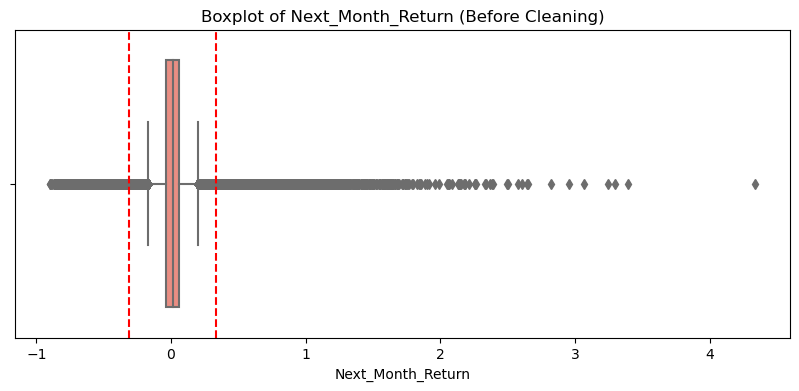

   ✅ Removed 29023 rows. New shape: (2598201, 25)


In [50]:
df_eda = clean_outliers_iqr(df_eda, column='Next_Month_Return', remove=True)

### Univariate Analysis

In [51]:
# univariate_analysis(df_eda)

### Multivariate Analysis

In [52]:
# multivariate_analysis(df_eda)

🔴 --- BEFORE FILTERING ---
📊 --- 1. UNIVARIATE ANALYSIS: Next_Month_Return ---


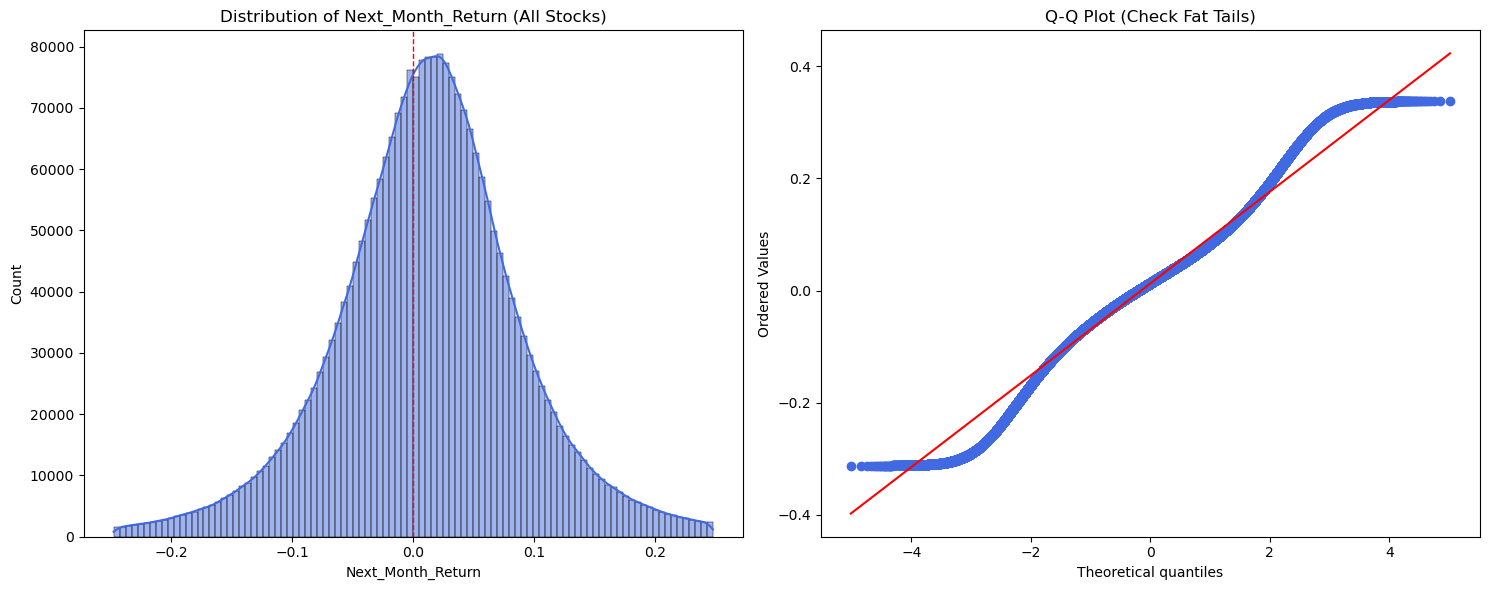

📈 Statistical Summary (N=2598201):
- Mean Return: 0.0127
- Volatility (Std): 0.0826
- Skewness: -0.0197 (ปกติ/สมมาตร)
- Kurtosis: 1.4812 (Normal)

🛡️ --- 2. CRISIS FILTERING (Regime-Based) ---
🎯 Strategy: Remove Top 10% High Volatility Periods
   (Cutoff ATR (Volatility) > 0.7386)
✂️ Removed: 259820 rows (10.00%)
✅ Remaining Data: 2338381 rows (Clean Data)

🟢 --- AFTER FILTERING (Ready for Training) ---
📊 --- 1. UNIVARIATE ANALYSIS: Next_Month_Return ---


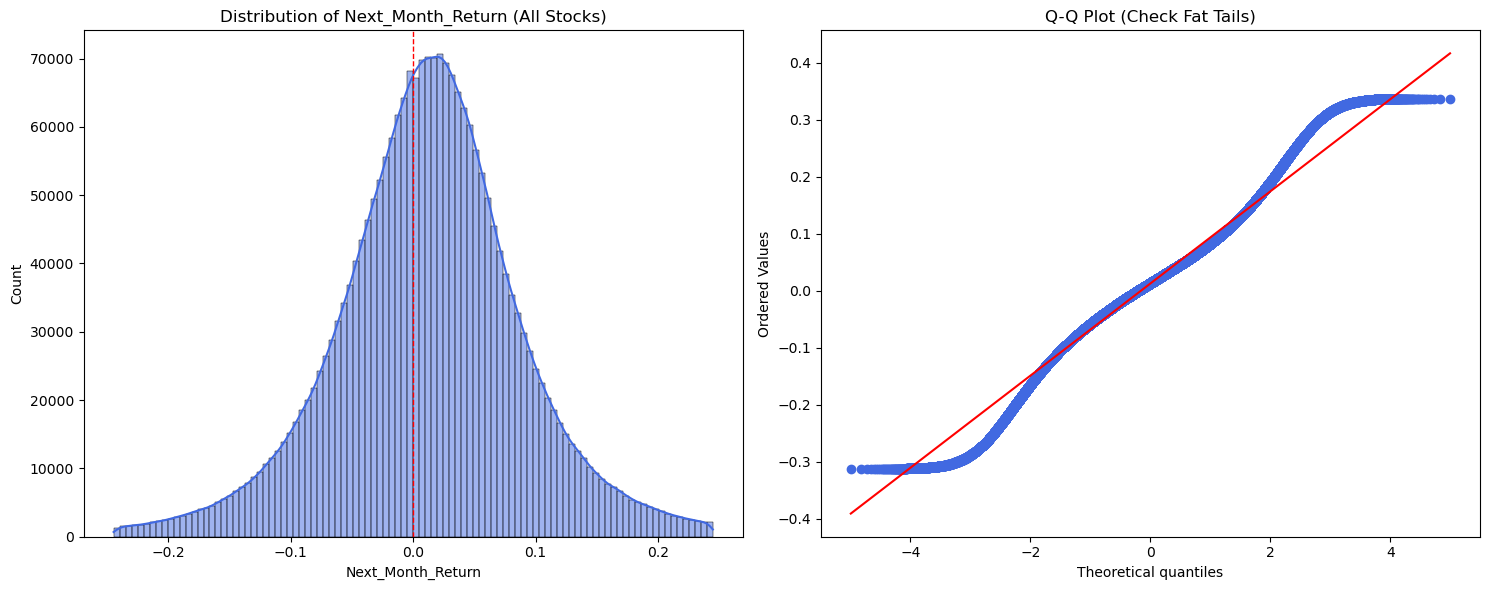

📈 Statistical Summary (N=2338381):
- Mean Return: 0.0131
- Volatility (Std): 0.0816
- Skewness: -0.0072 (ปกติ/สมมาตร)
- Kurtosis: 1.5000 (Normal)

🔗 --- 3. MULTIVARIATE ANALYSIS (Stationary Only) ---


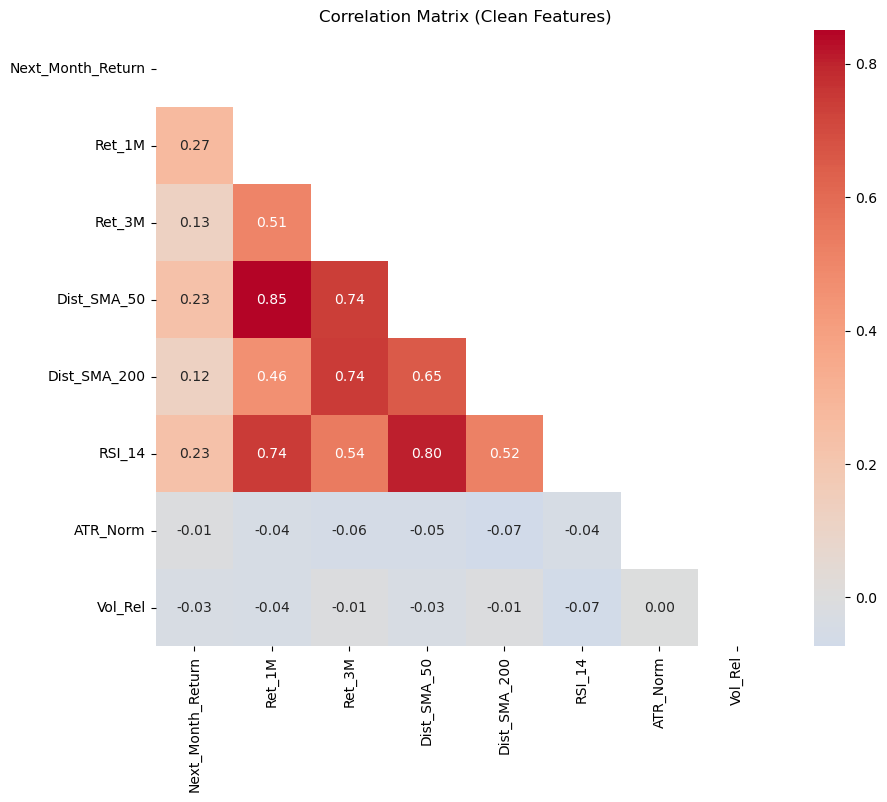

📌 Tip: ดูแถว 'Next_Month_Return' ว่าตัวไหนสัมพันธ์เยอะสุด (สีเข้ม)

📝 CONCLUSION:
Kurtosis ลดลงจาก 1.48 -> 1.50


In [53]:
df_final_ready = run_project_eda(df_eda)

### Clear Outlier


✂️ --- 3. TARGET CLIPPING (Removing Top/Bottom 1.0-99.0%) ---
📉 Return Range Allowed: -21.51% to 24.01%
❌ Removed Extreme Jumps: 51964 rows

🟢 --- FINAL CHECK ---
📊 --- 1. UNIVARIATE ANALYSIS: Next_Month_Return ---


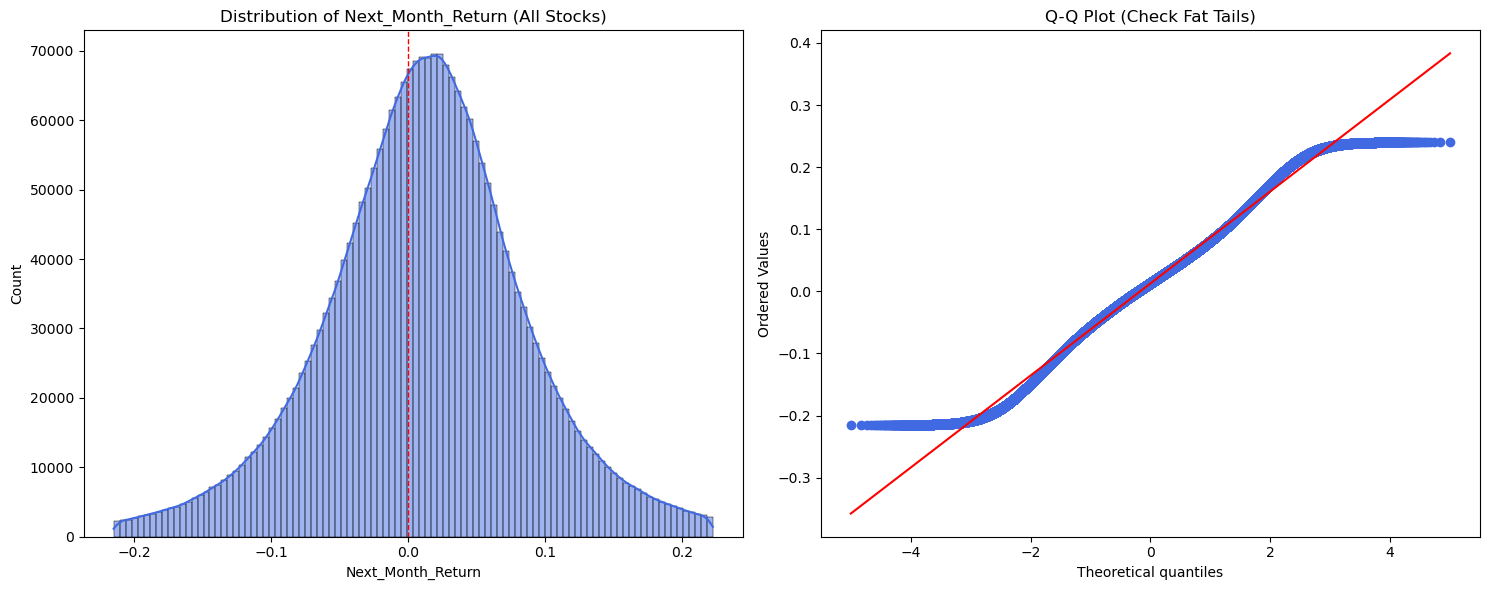

📈 Statistical Summary (N=2546237):
- Mean Return: 0.0127
- Volatility (Std): 0.0742
- Skewness: -0.0241 (ปกติ/สมมาตร)
- Kurtosis: 0.4231 (Normal)

🔥 Final Verdict:
Kurtosis Started: 20.11
Kurtosis Now:     0.4231
✅ Excellent! ข้อมูลพร้อมสำหรับการเทรนโมเดลให้แม่นยำแล้ว


In [54]:
def remove_extreme_returns(df, target_col='Next_Month_Return', lower_q=0.01, upper_q=0.99):
    """
    ตัดข้อมูลที่มีผลตอบแทน 'เวอร์เกินจริง' (Top/Bottom 1%) ออก
    เพื่อลด Kurtosis และทำให้โมเดลโฟกัสที่การเคลื่อนไหวปกติ
    """
    print(f"\n✂️ --- 3. TARGET CLIPPING (Removing Top/Bottom {lower_q*100}-{upper_q*100}%) ---")
    
    # หาขอบเขตล่างและบน (Percentile ที่ 1 และ 99)
    lower_bound = df[target_col].quantile(lower_q)
    upper_bound = df[target_col].quantile(upper_q)
    
    # Filter
    df_trimmed = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)].copy()
    
    print(f"📉 Return Range Allowed: {lower_bound*100:.2f}% to {upper_bound*100:.2f}%")
    print(f"❌ Removed Extreme Jumps: {len(df) - len(df_trimmed)} rows")
    
    return df_trimmed

# --- ลงมือทำ ---
# 1. ใช้ df_clean (ที่ผ่านการตัด Crisis มาแล้ว) มาตัด Extreme Return ต่อ
df_ready = remove_extreme_returns(df_eda)

# 2. เช็ค Kurtosis ครั้งสุดท้าย
print("\n🟢 --- FINAL CHECK ---")
kurt_final = univariate_analysis_pro(df_ready, target_col='Next_Month_Return')

print(f"\n🔥 Final Verdict:")
print(f"Kurtosis Started: 20.11")
print(f"Kurtosis Now:     {kurt_final:.4f}")

if kurt_final < 5:
    print("✅ Excellent! ข้อมูลพร้อมสำหรับการเทรนโมเดลให้แม่นยำแล้ว")
else:
    print("⚠️ Better, but still high. (อาจต้องยอมรับว่าธรรมชาติหุ้นรายตัวมันเป็นแบบนี้)")

In [55]:
# ==========================================
# FEATURE ELIMINATION PIPELINE
# ==========================================

# 1. กำหนดลิสต์ของตัวแปรที่เป็น Noise, Data Leakage หรือไม่มี Predictive Power
columns_to_drop = [
    'Open', 'High', 'Low', 'Close', 'Volume',  # กลุ่ม Absolute Price (Tree-based model ไม่ชอบ)
    'GDP',                                     # กลุ่ม Lagging/Synthetic Data (ข้อมูลไม่สะท้อนความจริงรายวัน)
    'Month'                                    # กลุ่ม Seasonality Trap (หลีกเลี่ยงการจำของ Model)
]

# 2. จัดการกลุ่ม Sector Dummies (กรณีที่คุณทำนาย Index S&P 500 รวม ไม่ใช่หุ้นรายตัว)
# ใช้ List Comprehension กวาดคอลัมน์ที่ขึ้นต้นด้วย 'Sector_' ทั้งหมดทิ้งอัตโนมัติ (Smart & Clean)
sector_columns = [col for col in df_eda.columns if str(col).startswith('Sector_')]
columns_to_drop.extend(sector_columns)

# 3. Execute Drop
# Note: การใช้ errors='ignore' เป็น Best Practice เพื่อให้ Pipeline ทำงานต่อได้แม้คอลัมน์ไม่มีอยู่จริง
df_eda   = df_eda.drop(columns=columns_to_drop, errors='ignore')

# 4. Report ผลลัพธ์ (สไตล์ Results-Driven)
print(f"🚨 Dropped {len(columns_to_drop)} unnecessary features.")
print(f"✅ Remaining Features for Modeling: {df_eda.shape[1] - 1}") # ลบ 1 สมมติว่าเป็น Target Column

🚨 Dropped 7 unnecessary features.
✅ Remaining Features for Modeling: 17


In [56]:
df_eda.describe()

,Adj_close,US10Y,YieldCurve,CorpSpread,VIX,Date_added,Ret_1M,Ret_3M,Ret_6M,Dist_SMA_50,Dist_SMA_200,ATR_Norm,Vol_Rel,RSI_14,MACD,Next_Month_Return,Target_Class
count,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2598201,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06,2.598201e+06
mean,7.092185e+01,3.063585e+00,1.137792e+00,1.563495e+00,1.961806e+01,1998-01-03 00:22:23.652165376,1.355546e-02,3.984611e-02,7.944136e-02,1.270211e-02,5.027273e-02,3.146831e-01,1.011665e+00,5.275267e+01,2.586551e-01,1.267147e-02,5.804328e-01
min,3.052100e-02,5.200000e-01,-1.080000e+00,7.900000e-01,9.140000e+00,1900-01-01 00:00:00,-8.980932e-01,-9.530898e-01,-9.815466e-01,-9.059197e-01,-9.707758e-01,6.050109e-03,0.000000e+00,6.942479e-02,-3.944062e+02,-3.121069e-01,0.000000e+00
25%,1.771393e+01,2.080000e+00,2.800000e-01,1.090000e+00,1.372000e+01,1985-10-31 00:00:00,-3.315046e-02,-4.456235e-02,-4.771378e-02,-2.697374e-02,-3.278360e-02,5.304216e-02,7.227868e-01,4.453531e+01,-2.188119e-01,-3.308482e-02,0.000000e+00
50%,3.509555e+01,2.900000e+00,1.200000e+00,1.380000e+00,1.752000e+01,2004-09-01 00:00:00,1.357767e-02,3.759914e-02,6.889334e-02,1.623662e-02,5.495579e-02,1.810409e-01,9.127162e-01,5.302150e+01,1.080592e-01,1.346353e-02,1.000000e+00
75%,7.241789e+01,4.090000e+00,1.920000e+00,1.720000e+00,2.311000e+01,2015-09-03 00:00:00,5.876918e-02,1.182715e-01,1.856494e-01,5.557719e-02,1.345774e-01,4.163011e-01,1.168241e+00,6.118170e+01,5.525594e-01,5.842390e-02,1.000000e+00
max,7.709270e+03,5.870000e+00,2.910000e+00,6.560000e+00,8.269000e+01,2023-12-18 00:00:00,4.335227e+00,6.789735e+00,9.295774e+00,1.864561e+00,3.413325e+00,1.775963e+01,2.000000e+01,9.984914e+01,2.322756e+02,3.375439e-01,1.000000e+00
std,1.646772e+02,1.203776e+00,9.557975e-01,8.213419e-01,8.275481e+00,NaN,9.431167e-02,1.650152e-01,2.486211e-01,8.226444e-02,1.646697e-01,5.234542e-01,5.158537e-01,1.186782e+01,3.444300e+00,8.259265e-02,4.934883e-01


Fetching S&P 500 data...


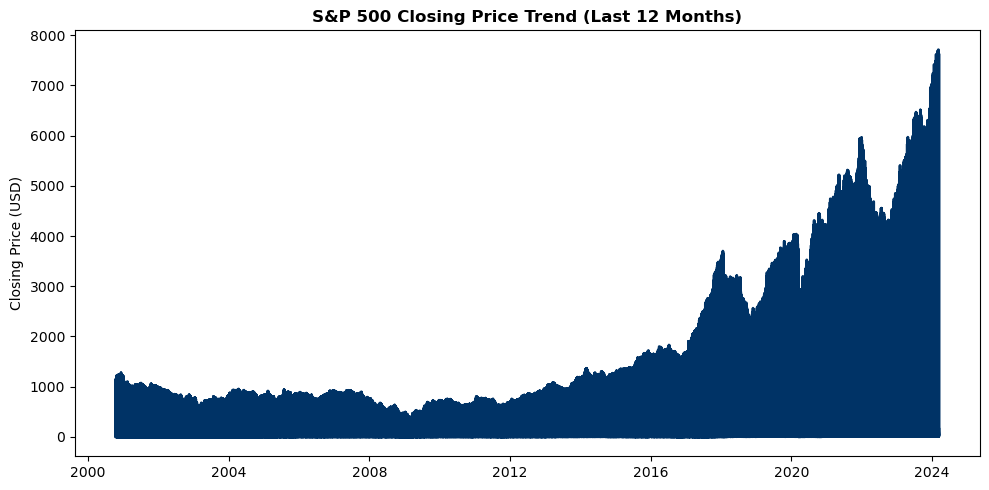

In [57]:
# ==========================================
# 1. S&P 500 Line Chart (Trend ราคาปิด)
# ==========================================
print("Fetching S&P 500 data...")

plt.figure(figsize=(10, 5))
plt.plot(df_eda.index, df_eda['Adj_close'], color='#003366', linewidth=2)

plt.title('S&P 500 Closing Price Trend (Last 12 Months)', fontweight='bold')
plt.ylabel('Closing Price (USD)')
plt.xlabel('')

plt.tight_layout()


In [58]:
df_eda.head()

,Name,Adj_close,US10Y,YieldCurve,CorpSpread,VIX,Date_added,Ret_1M,Ret_3M,Ret_6M,Dist_SMA_50,Dist_SMA_200,ATR_Norm,Vol_Rel,RSI_14,MACD,Next_Month_Return,Target_Class
Date,,,,,,,,,,,,,,,,,,
2000-10-16,IRM,4.042944,5.74,-0.15,1.76,26.79,2009-01-06,0.056818,0.052831,0.016394,0.024605,0.038328,1.378184,0.418949,51.230454,0.054815,-0.116910,0
2000-10-16,WST,4.235402,5.74,-0.15,1.76,26.79,2020-05-22,0.068948,0.134527,-0.039007,0.060254,-0.043539,0.373708,1.581538,55.374507,0.075041,-0.046816,0
2000-10-16,EA,25.039354,5.74,-0.15,1.76,26.79,2002-07-22,0.123796,0.227648,0.693264,0.050831,0.262482,0.092672,0.834810,54.492211,0.120198,0.174734,1
2000-10-16,APH,3.248775,5.74,-0.15,1.76,26.79,2008-09-30,0.018378,-0.083658,0.011815,-0.007606,0.138499,0.152502,1.020081,53.353407,-0.053395,0.044118,1
2000-10-16,BKNG,34.411938,5.74,-0.15,1.76,26.79,2009-11-06,-0.774510,-0.856474,-0.909980,-0.721343,-0.876929,0.343997,0.325919,23.637400,-30.190684,-0.117318,0


In [59]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2598201 entries, 2000-10-16 to 2024-03-11
Data columns (total 18 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Name               object        
 1   Adj_close          float64       
 2   US10Y              float64       
 3   YieldCurve         float64       
 4   CorpSpread         float64       
 5   VIX                float64       
 6   Date_added         datetime64[ns]
 7   Ret_1M             float64       
 8   Ret_3M             float64       
 9   Ret_6M             float64       
 10  Dist_SMA_50        float64       
 11  Dist_SMA_200       float64       
 12  ATR_Norm           float64       
 13  Vol_Rel            float64       
 14  RSI_14             float64       
 15  MACD               float64       
 16  Next_Month_Return  float64       
 17  Target_Class       int32         
dtypes: datetime64[ns](1), float64(15), int32(1), object(1)
memory usage: 366.7+ MB


# Method

### XGBoost

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  # เพิ่มเข้ามา
from sklearn.preprocessing import StandardScaler      # เพิ่มการ Scale ข้อมูล
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_score, recall_score

# [UPDATED CODE]
def run_model_battle(df, target_col='Target_Class', test_ratio=0.2, extra_drop_cols=None):
    """
    ฟังก์ชันเปรียบเทียบประสิทธิภาพ 4 โมเดล (LR, RF, XGB, LGBM)
    พร้อมระบบ Scaling ข้อมูล และ Feature Elimination
    """
    print("⚔️ PREPARING DATA FOR BATTLE...")
    
    print(f"📦 Raw Data Dimension: {df.shape[0]} Rows, {df.shape[1]} Columns")
    # --- 1. PREPARE DATA ---
    data = df.sort_index().copy()
    
    # 1.1 จัดการลิสต์ตัวแปรที่ต้องการลบ (รวมของเก่า + ของใหม่)
    # Default ที่ต้องลบแน่ๆ (ห้ามเอาไปเทรน)
    base_drop_cols = ['Name', 'Date_added', 'Open', 'High', 'Low', 'Close', 'Volume', 'GDP', 'Month']
    
    # เพิ่ม Sector Dummies เข้าไปในลิสต์ที่จะลบทิ้ง (ถ้ามี)
    sector_cols = [col for col in data.columns if str(col).startswith('Sector_')]
    base_drop_cols.extend(sector_cols)
    
    # รวมกับตัวแปรพิเศษที่ User ส่งเข้ามาผ่าน extra_drop_cols (ถ้ามี)
    if extra_drop_cols:
        base_drop_cols.extend(extra_drop_cols)
        
    # 1.2 ลบตัวแปรอย่างปลอดภัย (ลบเฉพาะตัวที่มีอยู่ใน DataFrame ป้องกัน Error)
    existing_drop_cols = [c for c in base_drop_cols if c in data.columns]
    if existing_drop_cols:
        data = data.drop(columns=existing_drop_cols)
        print(f"🗑️ Dropped {len(existing_drop_cols)} Features: {existing_drop_cols}")
        
    # One-Hot Encoding
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
    
    # Define Columns
    ignore_cols = [target_col, 'Next_Month_Return']
    features = [c for c in data.columns if c not in ignore_cols]
    
    # Filter Numeric (ป้องกันตัวแปร String หลุดเข้าไป)
    X = data[features].select_dtypes(include=['number', 'bool'])
    y = data[target_col]
    
    # Time-Series Split
    split_idx = int(len(X) * (1 - test_ratio))
    X_train_raw, X_test_raw = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    train_pct = (len(X_train_raw) / len(X)) * 100
    test_pct = (len(X_test_raw) / len(X)) * 100
    print("\n🪓 DATA SPLIT (Time-Series):")
    print(f"   Train Set ({train_pct:.0f}%): {len(X_train_raw)} Rows")
    print(f"   Test Set  ({test_pct:.0f}%): {len(X_test_raw)} Rows")
    
    # --- เพิ่มขั้นตอน Scaling (สำคัญมากสำหรับ Logistic Regression) ---
    scaler = StandardScaler()
    
    # [แก้ไขตรงนี้]: นำผลลัพธ์ที่เป็น Numpy Array มาประกอบร่างกลับเป็น DataFrame พร้อมแปะชื่อคอลัมน์เดิมกลับเข้าไป
    X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), 
                           columns=X_train_raw.columns, 
                           index=X_train_raw.index)
                           
    X_test = pd.DataFrame(scaler.transform(X_test_raw), 
                          columns=X_test_raw.columns, 
                          index=X_test_raw.index)

    # --- 2. DEFINE MODELS ---
    models = {
        'Logistic Regression 📈': LogisticRegression(
            max_iter=1000, C=1.0, random_state=42
        ),
        'Random Forest 🌲': RandomForestClassifier(
            n_estimators=200, max_depth=5, min_samples_leaf=50, 
            random_state=42, n_jobs=-1
        ),
        'XGBoost 🚀': xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5, 
            subsample=0.8, colsample_bytree=0.8, 
            gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, n_jobs=-1, eval_metric='logloss'
        ),
        'LightGBM ⚡': lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=42, n_jobs=-1, verbose=-1
        )
    }
    
    results = {}
    
    # --- 3. TRAINING LOOP ---
    plt.figure(figsize=(12, 8))
    print("\n🏁 STARTING BATTLE...")
    
    for name, model in models.items():
        print(f"   training {name}...")
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)
        
        # Calculate Metrics
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_probs)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        
        results[name] = {
            'model_obj' : model,
            'auc': auc,
            'accuracy': acc,
            'precision': prec,
            'recall': rec
        }
        
        # Plot ROC
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        label_text = f'{name} (ACC={acc:.3f}, Rec={rec:.2f})'
        plt.plot(fpr, tpr, lw=2, label=label_text)

    # --- 4. FINALIZE PLOT ---
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('🏆 Model Battle: Performance Comparison including Logistic Regression', fontsize=16)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # --- 5. PRINT LEADERBOARD ---
    print("\n📊 --- FINAL LEADERBOARD ---")
    leaderboard = pd.DataFrame(results).T.sort_values(by='accuracy', ascending=False)
    print(leaderboard)
    
    return results, X_test, y_test

⚔️ PREPARING DATA FOR BATTLE...
📦 Raw Data Dimension: 2546237 Rows, 25 Columns
🗑️ Dropped 9 Features: ['Name', 'Date_added', 'Open', 'High', 'Low', 'Close', 'Volume', 'GDP', 'Month']

🪓 DATA SPLIT (Time-Series):
   Train Set (80%): 2036989 Rows
   Test Set  (20%): 509248 Rows

🏁 STARTING BATTLE...
   training Logistic Regression 📈...
   training Random Forest 🌲...
   training XGBoost 🚀...
   training LightGBM ⚡...


c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


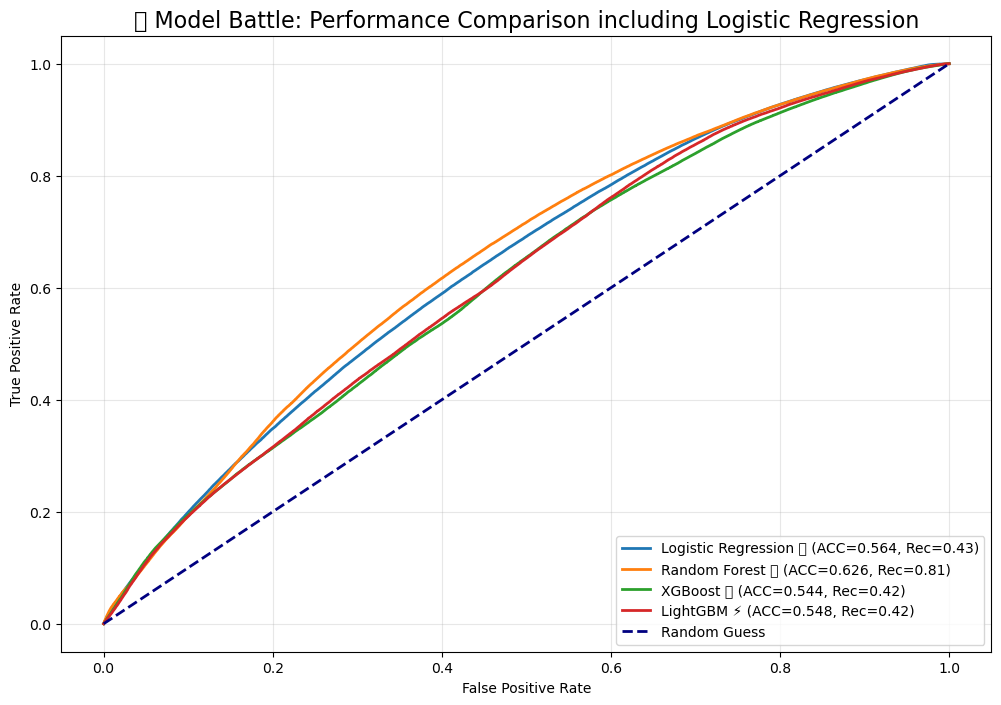


📊 --- FINAL LEADERBOARD ---
                                                               model_obj  \
Random Forest 🌲        (DecisionTreeClassifier(max_depth=5, max_featu...   
Logistic Regression 📈  LogisticRegression(max_iter=1000, random_state...   
LightGBM ⚡             LGBMClassifier(colsample_bytree=0.8, learning_...   
XGBoost 🚀              XGBClassifier(base_score=None, booster=None, c...   

                            auc  accuracy precision    recall  
Random Forest 🌲        0.647785    0.6263  0.632323  0.805621  
Logistic Regression 📈  0.637603  0.563517  0.679852  0.426806  
LightGBM ⚡             0.616263  0.547983  0.653989  0.421017  
XGBoost 🚀              0.612125  0.543639  0.648878  0.415278  


In [61]:
# รันการแข่งขัน และรับค่า 3 ตัวแปรเก็บไว้
results, X_test_battle, y_test_battle = run_model_battle(df_ready)

In [62]:
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model_obj = results[best_model_name]['model_obj'] 
best_auc = results[best_model_name]['auc']

print(f"👑 The Winner is: {best_model_name}")
print(f"⭐ AUC Score: {best_auc:.4f}")

👑 The Winner is: Random Forest 🌲
⭐ AUC Score: 0.6478


## AUC - ROC CURVE

📌 Analyzing Results for: Random Forest 🌲


C:\Users\Bookky\AppData\Local\Temp\ipykernel_36932\2956029339.py:38: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  plt.tight_layout()
c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


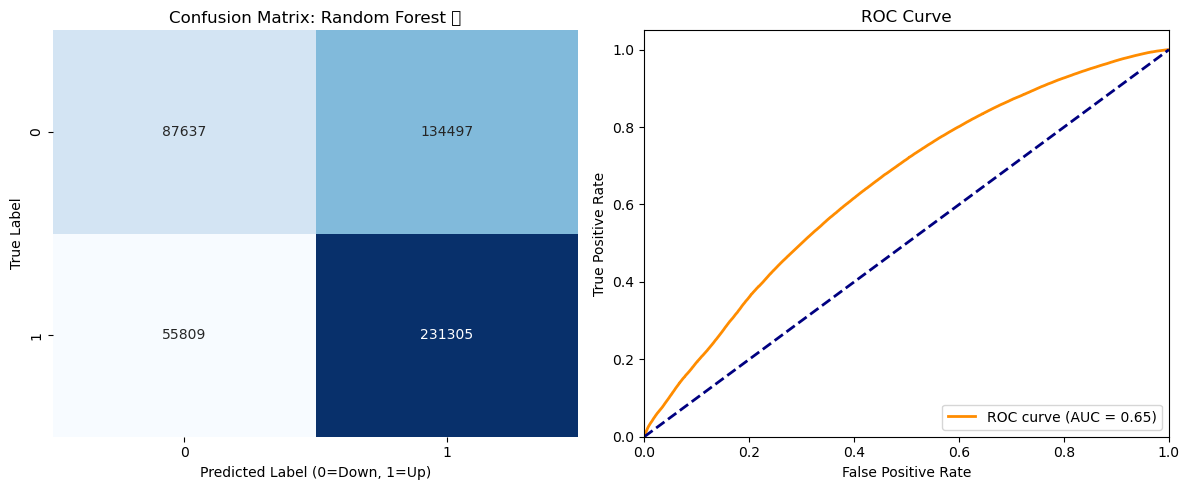


📝 Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.39      0.48    222134
           1       0.63      0.81      0.71    287114

    accuracy                           0.63    509248
   macro avg       0.62      0.60      0.59    509248
weighted avg       0.62      0.63      0.61    509248



In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

def report_best_model_results(model, X_test, y_test, model_name):
    print(f"📌 Analyzing Results for: {model_name}")
    
    # 1. ทำนายผล (Class และ Probability)
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. สร้าง Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(12, 5))
    
    # วาด Confusion Matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Label (0=Down, 1=Up)')
    plt.ylabel('True Label')
    
    # 3. วาด ROC Curve (ใช้ฟังก์ชันที่คุณเตรียมไว้)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    # 4. แสดงค่า Precision, Recall, F1-Score
    print("\n📝 Classification Report:")
    print(classification_report(y_test, y_pred))

# เรียกใช้งานฟังก์ชัน
report_best_model_results(best_model_obj, X_test_battle, y_test_battle, best_model_name)

In [64]:
def plot_custom_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: S&P 500 Prediction')
    plt.show()

In [ ]:
y_pred_best = best_model_obj.predict(X_test_battle)
plot_custom_confusion_matrix(y_test_battle, y_pred_best)

### Model Training & Evalution

# BackTest

📅 STARTING MONTHLY HOLD BACKTEST using RandomForestClassifier
   (Threshold > 0.55)...


C:\Users\Bookky\AppData\Local\Temp\ipykernel_36932\844454961.py:81: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
c:\Users\Bookky\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


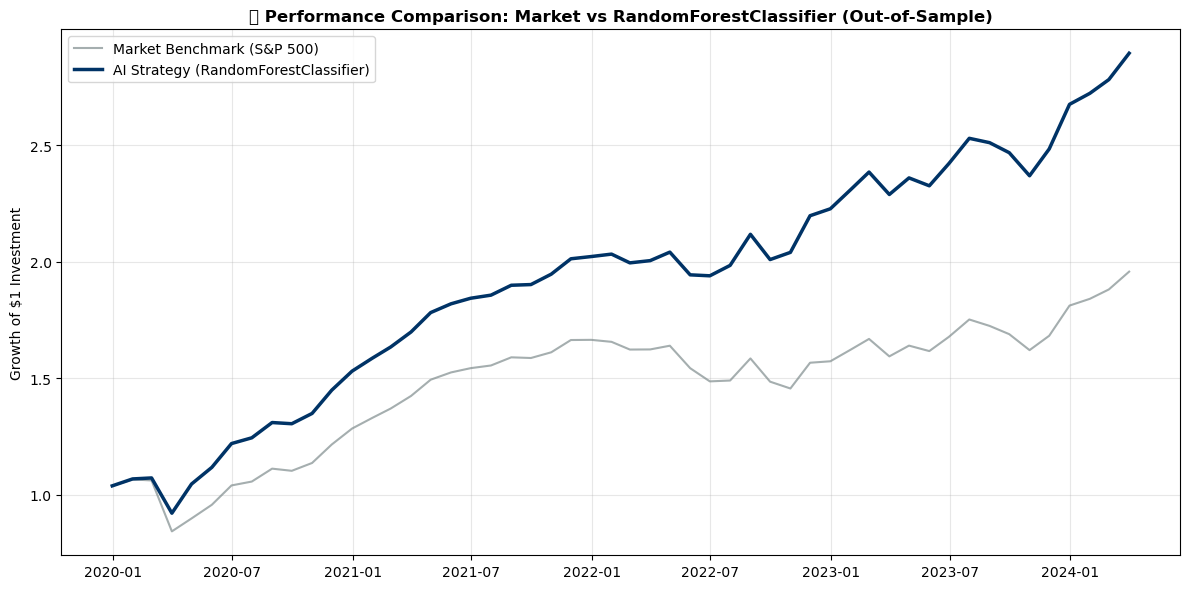


📊 FINAL REPORT:
Model Used: RandomForestClassifier
Benchmark Return: 95.77%
AI Strategy Return: 189.48%


In [69]:

def run_final_monthly_backtest(model, df, scaler=None, threshold=0.55):
    """
    ฟังก์ชัน Backtest ฉบับสมบูรณ์ (Data Pipeline ตรงกับตอน Train 100%)
    """
    model_name = type(model).__name__
    print(f"📅 STARTING MONTHLY HOLD BACKTEST using {model_name}")
    print(f"   (Threshold > {threshold})...")
    
    # --- 1. PREPARE DATA (ต้องเหมือนตอน Train ทุกกระเบียดนิ้ว) ---
    data = df.sort_index().copy()
    
    # 1.1 ลบตัวแปรขยะแบบเดียวกับตอน Train
    base_drop_cols = ['Name', 'Date_added', 'Open', 'High', 'Low', 'Close', 'Volume', 'GDP', 'Month']
    sector_cols = [col for col in data.columns if str(col).startswith('Sector_')]
    base_drop_cols.extend(sector_cols)
    
    existing_drop_cols = [c for c in base_drop_cols if c in data.columns]
    if existing_drop_cols:
        data = data.drop(columns=existing_drop_cols)
        
    # 1.2 ทำ One-Hot Encoding
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

    # 1.3 แบ่งข้อมูล Test Set (20% หลังสุด)
    split_idx = int(len(data) * 0.8)
    test_data = data.iloc[split_idx:].copy()
    
    # Clean Data & Clip Return ของ Test Set
    if 'Adj_close' in test_data.columns:
        test_data = test_data[test_data['Adj_close'] >= 5.0]
    test_data['Next_Month_Return'] = test_data['Next_Month_Return'].clip(lower=-0.5, upper=0.5)

    # --- 2. SELECT FEATURES & SCALE DATA ---
    ignore_cols = ['Target_Class', 'Next_Month_Return', 'Signal']
    features = [c for c in test_data.columns if c not in ignore_cols]
    
    # กรองเฉพาะตัวเลข
    X_test_raw = test_data[features].select_dtypes(include=['number', 'bool'])
    
    # 🚨 สำคัญที่สุด: ถ้าตอนเทรนมี Scaler ต้องเอามา Scale ตรงนี้ด้วย!
    if scaler is not None:
        X_test = scaler.transform(X_test_raw)
    else:
        X_test = X_test_raw

    # --- 3. PREDICT SIGNAL ---
    # Predict
    try:
        # กรณี X_test เป็น DataFrame
        probs = model.predict_proba(X_test.astype('float32'))[:, 1]
    except:
        # กรณี X_test เป็น Numpy Array (ผลจาก Scaler)
        probs = model.predict_proba(X_test)[:, 1]
        
    test_data['Signal'] = (probs >= threshold).astype(int)
    
    # --- 4. CALCULATE RETURNS (Monthly) ---
    monthly_benchmark = test_data.groupby(pd.Grouper(freq='M'))['Next_Month_Return'].mean().fillna(0)
    active_trades = test_data[test_data['Signal'] == 1]
    
    if len(active_trades) > 0:
        monthly_strategy = active_trades.groupby(pd.Grouper(freq='M'))['Next_Month_Return'].mean()
        monthly_strategy = monthly_strategy.reindex(monthly_benchmark.index).fillna(0)
    else:
        monthly_strategy = pd.Series(0, index=monthly_benchmark.index)

    # --- 5. PLOT ---
    cum_bench = (1 + monthly_benchmark).cumprod()
    cum_strat = (1 + monthly_strategy).cumprod()

    plt.figure(figsize=(12, 6))
    plt.plot(cum_bench.index, cum_bench, label='Market Benchmark (S&P 500)', color='#7F8C8D', alpha=0.7)
    plt.plot(cum_strat.index, cum_strat, label=f'AI Strategy ({model_name})', color='#003366', linewidth=2.5)
    
    plt.title(f'🏆 Performance Comparison: Market vs {model_name} (Out-of-Sample)', fontweight='bold')
    plt.ylabel('Growth of $1 Investment')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # --- 6. REPORT ---
    bench_ret = cum_bench.iloc[-1] - 1
    strat_ret = cum_strat.iloc[-1] - 1
    
    print("\n📊 FINAL REPORT:")
    print(f"Model Used: {model_name}")
    print(f"Benchmark Return: {bench_ret:.2%}")
    print(f"AI Strategy Return: {strat_ret:.2%}")

run_final_monthly_backtest(best_model_obj, df, threshold=0.55)

🔍 Extracting Feature Names from Model...
✅ Found 14 features matching the model.
🚨 TOP 10 FEATURES ที่โมเดล RandomForestClassifier ให้ความสำคัญสูงสุด:
Ret_1M          0.294495
VIX             0.208615
RSI_14          0.170059
MACD            0.098346
Dist_SMA_50     0.096207
CorpSpread      0.037084
YieldCurve      0.027517
US10Y           0.024183
Ret_3M          0.021350
Dist_SMA_200    0.014388
dtype: float64


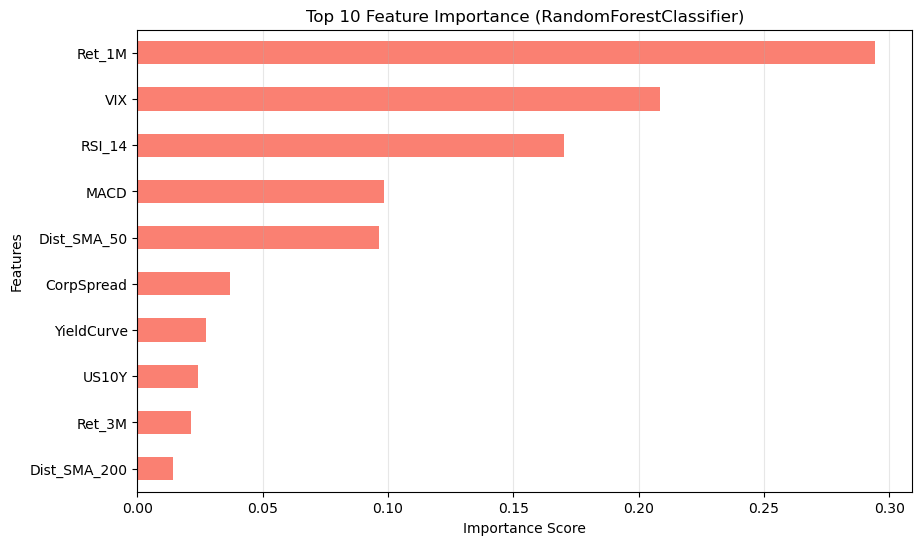

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def check_model_features(model, feature_names):
    """
    ฟังก์ชันตรวจสอบ Feature Importance ฉบับสมบูรณ์
    รองรับทั้ง Tree-based (RF, XGB, LGBM) และ Linear (Logistic Regression)
    """
    model_name = type(model).__name__
    
    # 1. ตรวจสอบประเภทของโมเดลและดึงค่าความสำคัญ
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        is_linear = False
    elif hasattr(model, 'coef_'):
        # สำหรับ Logistic Regression ใช้ค่าสัมบูรณ์ (Absolute) ของ Coef เป็นตัวบอกความสำคัญ
        importances = np.abs(model.coef_[0]) 
        actual_coefs = model.coef_[0] # เก็บค่าดิบไว้ดูทิศทาง (บวก/ลบ)
        is_linear = True
    else:
        print(f"❌ ไม่สามารถดึงค่าความสำคัญจากโมเดล {model_name} ได้")
        return
        
    # 2. ป้องกัน Error จำนวนชื่อคอลัมน์ไม่ตรงกับค่าที่โมเดลมี
    if len(feature_names) != len(importances):
        print(f"⚠️ คำเตือน: จำนวนชื่อ Feature ({len(feature_names)}) ไม่ตรงกับที่โมเดลมี ({len(importances)})")
        print("กำลังสร้างชื่อชั่วคราว (Dummy Names)...")
        feature_names = [f"Feature_{i}" for i in range(len(importances))]
        
    # 3. จัดการข้อมูลเพื่อเตรียมแสดงผลและพล็อตกราฟ
    if is_linear:
        # 🟢 สาย Linear (เช่น Logistic Regression)
        df_imp = pd.DataFrame({
            'Feature': feature_names,
            'Impact': importances,        # พลังที่ส่งผล (ไม่สนทิศทาง)
            'Coefficient': actual_coefs   # ทิศทาง (บวก=หุ้นขึ้น, ลบ=หุ้นลง)
        }).sort_values(by='Impact', ascending=False)
        
        print(f"🚨 TOP 10 FEATURES ที่โมเดล {model_name} ให้ความสำคัญสูงสุด:")
        print(df_imp[['Feature', 'Coefficient']].head(10))
        
        # เตรียมพล็อตกราฟแยกสี (เขียว=บวก, แดง=ลบ)
        plot_data = df_imp.head(20).set_index('Feature')['Coefficient']
        colors = ['mediumseagreen' if c > 0 else 'indianred' for c in plot_data]
        
        plt.figure(figsize=(10, 6))
        plot_data.plot(kind='barh', color=colors)
        plt.title(f'Top 10 Feature Coefficients ({model_name})')
        plt.xlabel('Coefficient Value (Green = Positive, Red = Negative Impact)')
        
    else:
        # 🌲 สาย Tree (เช่น Random Forest, XGBoost)
        feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        
        print(f"🚨 TOP 10 FEATURES ที่โมเดล {model_name} ให้ความสำคัญสูงสุด:")
        print(feature_imp.head(10))
        
        plt.figure(figsize=(10, 6))
        feature_imp.head(10).plot(kind='barh', color='salmon')
        plt.title(f'Top 10 Feature Importance ({model_name})')
        plt.xlabel('Importance Score')

    # ตกแต่งกราฟให้สวยงาม
    plt.gca().invert_yaxis() # เอาตัวที่สำคัญสุดไว้บนสุด
    plt.ylabel('Features')
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# ==========================================
# --- วิธีเรียกใช้งาน ---
# ==========================================

print("🔍 Extracting Feature Names from Model...")

feats = None

# เช็คก่อนว่ามีตัวแปร best_model_obj หรือไม่ (กัน NameError)
if 'best_model_obj' not in globals() and 'best_model_obj' not in locals():
    raise NameError("❌ ไม่พบตัวแปร 'best_model_obj' กรุณารันโค้ดส่วนค้นหา Best Model ก่อน!")

# 1. ดึงจาก Scikit-learn (RF, LR)
if hasattr(best_model_obj, 'feature_names_in_'):
    feats = list(best_model_obj.feature_names_in_)

# 2. ดึงจาก LightGBM
elif hasattr(best_model_obj, 'feature_name_'):
    feats = list(best_model_obj.feature_name_)

# 3. ดึงจาก XGBoost (ระวังเคสที่มันรีเทิร์น None)
elif hasattr(best_model_obj, 'get_booster'):
    booster_feats = best_model_obj.get_booster().feature_names
    if booster_feats is not None:
        feats = list(booster_feats)

# 4. ถ้า Model ไม่เก็บชื่อไว้ ให้ไปงัดออกมาจาก battle_results 
if feats is None:
    print("⚠️ Model doesn't have internal feature names. Trying to extract from variables...")
    if 'results' in globals() and isinstance(results, tuple) and len(results) >= 2:
        try:
            feats = list(results[1].columns)
        except Exception:
            pass
            
    # ดักเผื่อคุณยังดื้อใช้ชื่อ X_test_battle
    elif 'X_test_battle' in globals():
        feats = list(X_test_battle.columns)

# เช็คขั้นตอนสุดท้ายก่อนโยนเข้าฟังก์ชันพล็อตกราฟ
if feats is None or len(feats) == 0:
    raise ValueError("❌ สกัดชื่อ Feature ล้มเหลว! Model ของคุณถูก Train มาแบบไม่มีชื่อคอลัมน์ และหาตัวแปรอ้างอิงไม่เจอ")

print(f"✅ Found {len(feats)} features matching the model.")

# เรียกใช้งานฟังก์ชันที่อัปเกรดแล้ว
check_model_features(best_model_obj, feats)

In [71]:
for i, feature in enumerate(feats):
    print(f"{i+1}. {feature}")

1. Adj_close
2. US10Y
3. YieldCurve
4. CorpSpread
5. VIX
6. Ret_1M
7. Ret_3M
8. Ret_6M
9. Dist_SMA_50
10. Dist_SMA_200
11. ATR_Norm
12. Vol_Rel
13. RSI_14
14. MACD


Successfully saved image


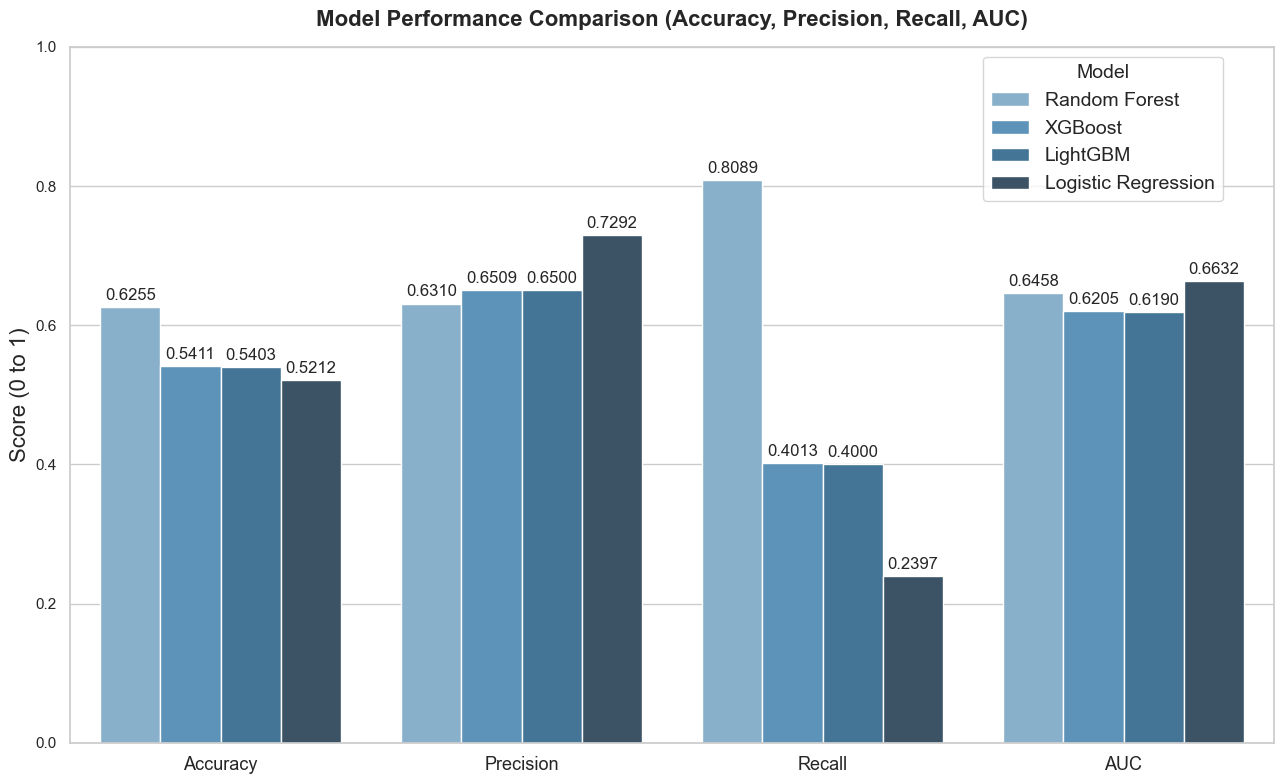

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Model': ['Random Forest']*4 + ['XGBoost']*4 + ['LightGBM']*4+ ['Logistic Regression']*4,
    'Metric': ['Accuracy', 'Precision', 'Recall', 'AUC'] * 4,
    'Score': [0.625532, 0.630984, 0.808853, 0.645849,   # <-- Random Forest
              0.541121, 0.650921, 0.401318, 0.62053,  # XGBoost
              0.540299, 0.65004, 0.399967, 0.618981,# <-- LightGBM
              0.521167, 0.729186, 0.239741, 0.66317]   # <-- Logistic Regression
}            
df = pd.DataFrame(data)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 8)) # ใช้ subplots แทน figure ตามคำแนะนำ และเพิ่มความกว้างเล็กน้อย

ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df, palette='Blues_d', ax=ax)

# ปรับขนาดของตัวอักษรด้านบน (Title) ซ้าย (Y-label) และ Legend (Model)
ax.set_title('Model Performance Comparison (Accuracy, Precision, Recall, AUC)', fontweight='bold', fontsize=16, pad=15)
ax.set_ylim(0, 1)
ax.set_ylabel('Score (0 to 1)', fontsize=16)
ax.set_xlabel('', fontsize=13 )

ax.tick_params(axis='x', labelsize=13)

# โชว์ตัวเลขบนแท่งกราฟ
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=12)

# ปรับขนาดกล่องและฟอนต์ Legend (Model) พร้อมย้ายตำแหน่งไม่ให้บังข้อมูล
ax.legend(bbox_to_anchor=(0.75, 1), loc='upper left', fontsize=14, title='Model', title_fontsize=14)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
print("Successfully saved image")